# 🏁 Intro

## Currently LCA and Circularity Performances

📖 Two types of Circularity Performances are identified according to **ISO 59004:2024**. Circularity literature complements this analysis ([Saidani et al., 2019](https://doi.org/10.1016/J.JCLEPRO.2018.10.014); [Hackenhaar et al., 2024](https://doi.org/10.1016/J.SPC.2024.01.018)):
- **Impact-based (LCIA-level):** ✅
- **Intrinsic (LCI-level):** ⚠️

## Impact-based Indicators in LCSA

[Hackenhaar et al. (2024)](https://doi.org/10.1016/j.spc.2024.01.018) argue that *Type III impact-based (LCIA-level) circularity indicators* should not be implemented in LCA due to double counting issues.

**Examples**
For instance, integrating the *Sustainable Circularity Index (SCI)* results in direct overlaps with existing metrics:
- Water depletion (LCA)
- Accidents at work (S-LCA)
- Value generated (LCC)

**Conclusion**: 🎯 **inventory-based circularity indicators (LCI-level)**

## ISO 59020 Indicators & LCA Mapping

### ISO 59020 resource flows

ISO59020:2024 defines resource flows for circularity indicators as:
- Internal circular flows
- External circular flows
- Non-circular outflows

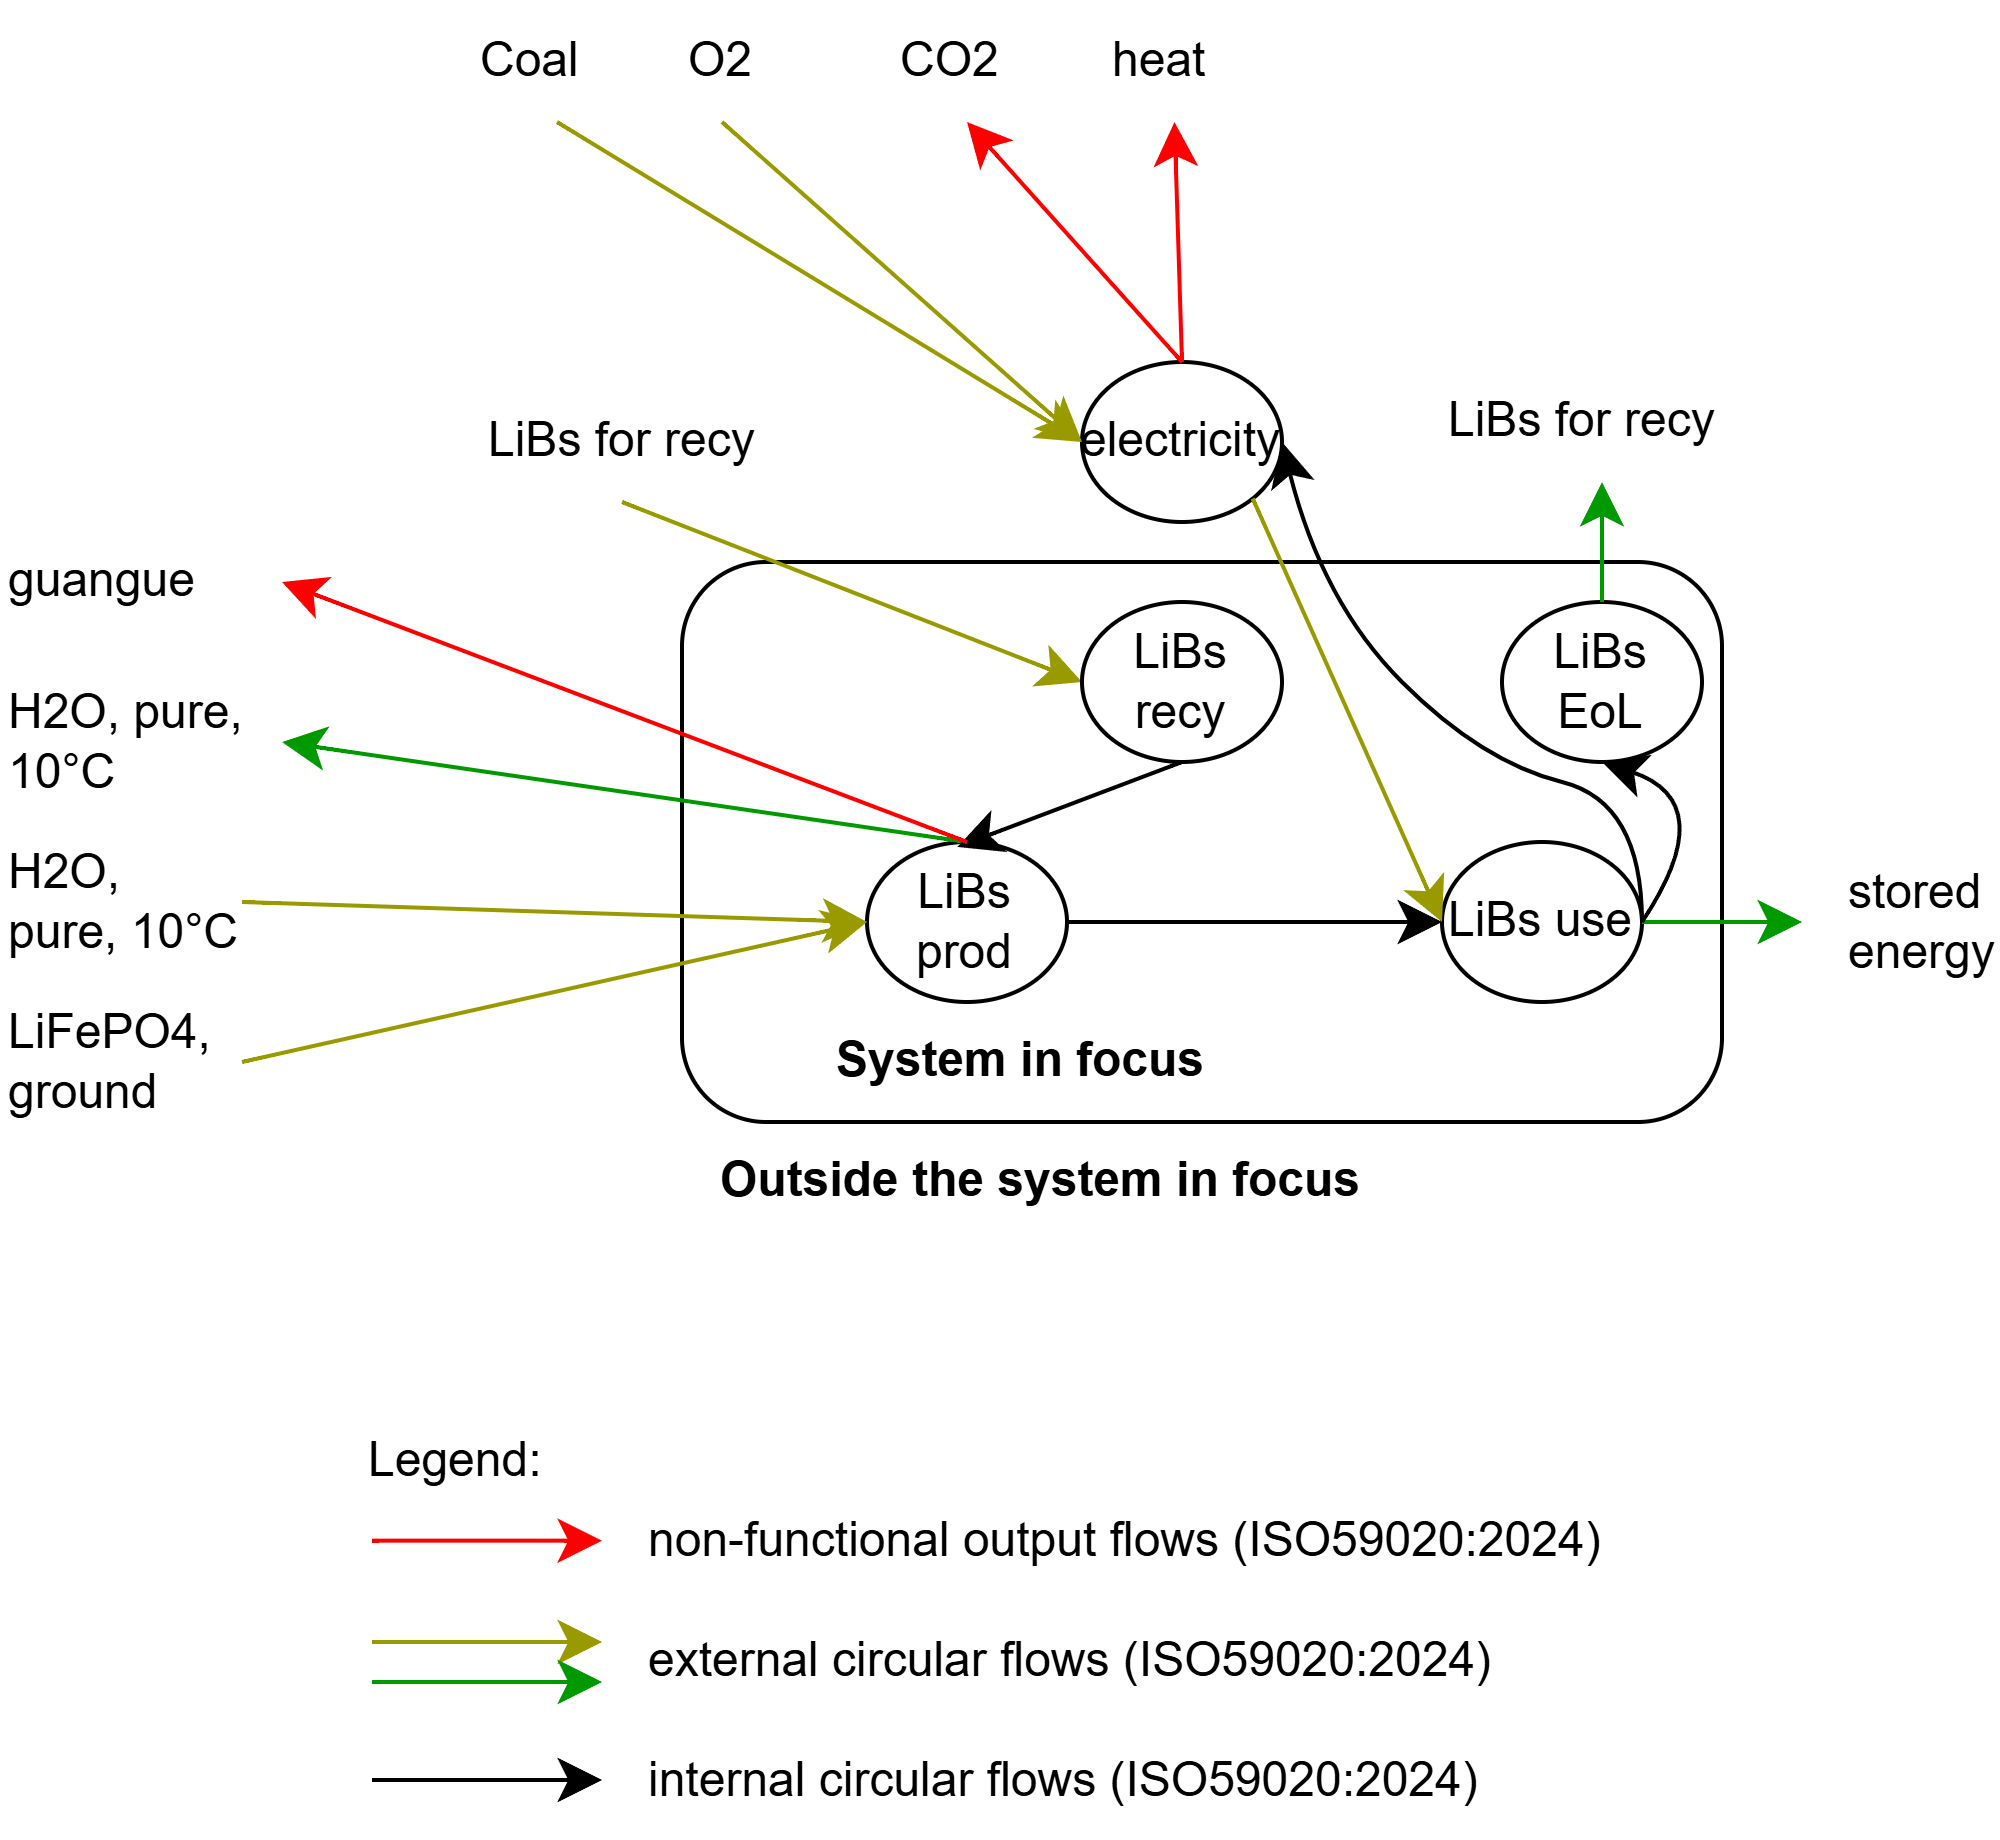

In [ ]:
from IPython.display import Image, display
# Diagram 1: ISO 59020 Resource Flows
display(Image(filename="conference/thursday/circularity_lci/figures/circularity_only.png", width=500))

**Observation 1**: These flows correspond to LCA flows, which ones?

For LCA product systems, these theoretically correspond to:
- Product flows (PF)
- Elementary flows (EF)

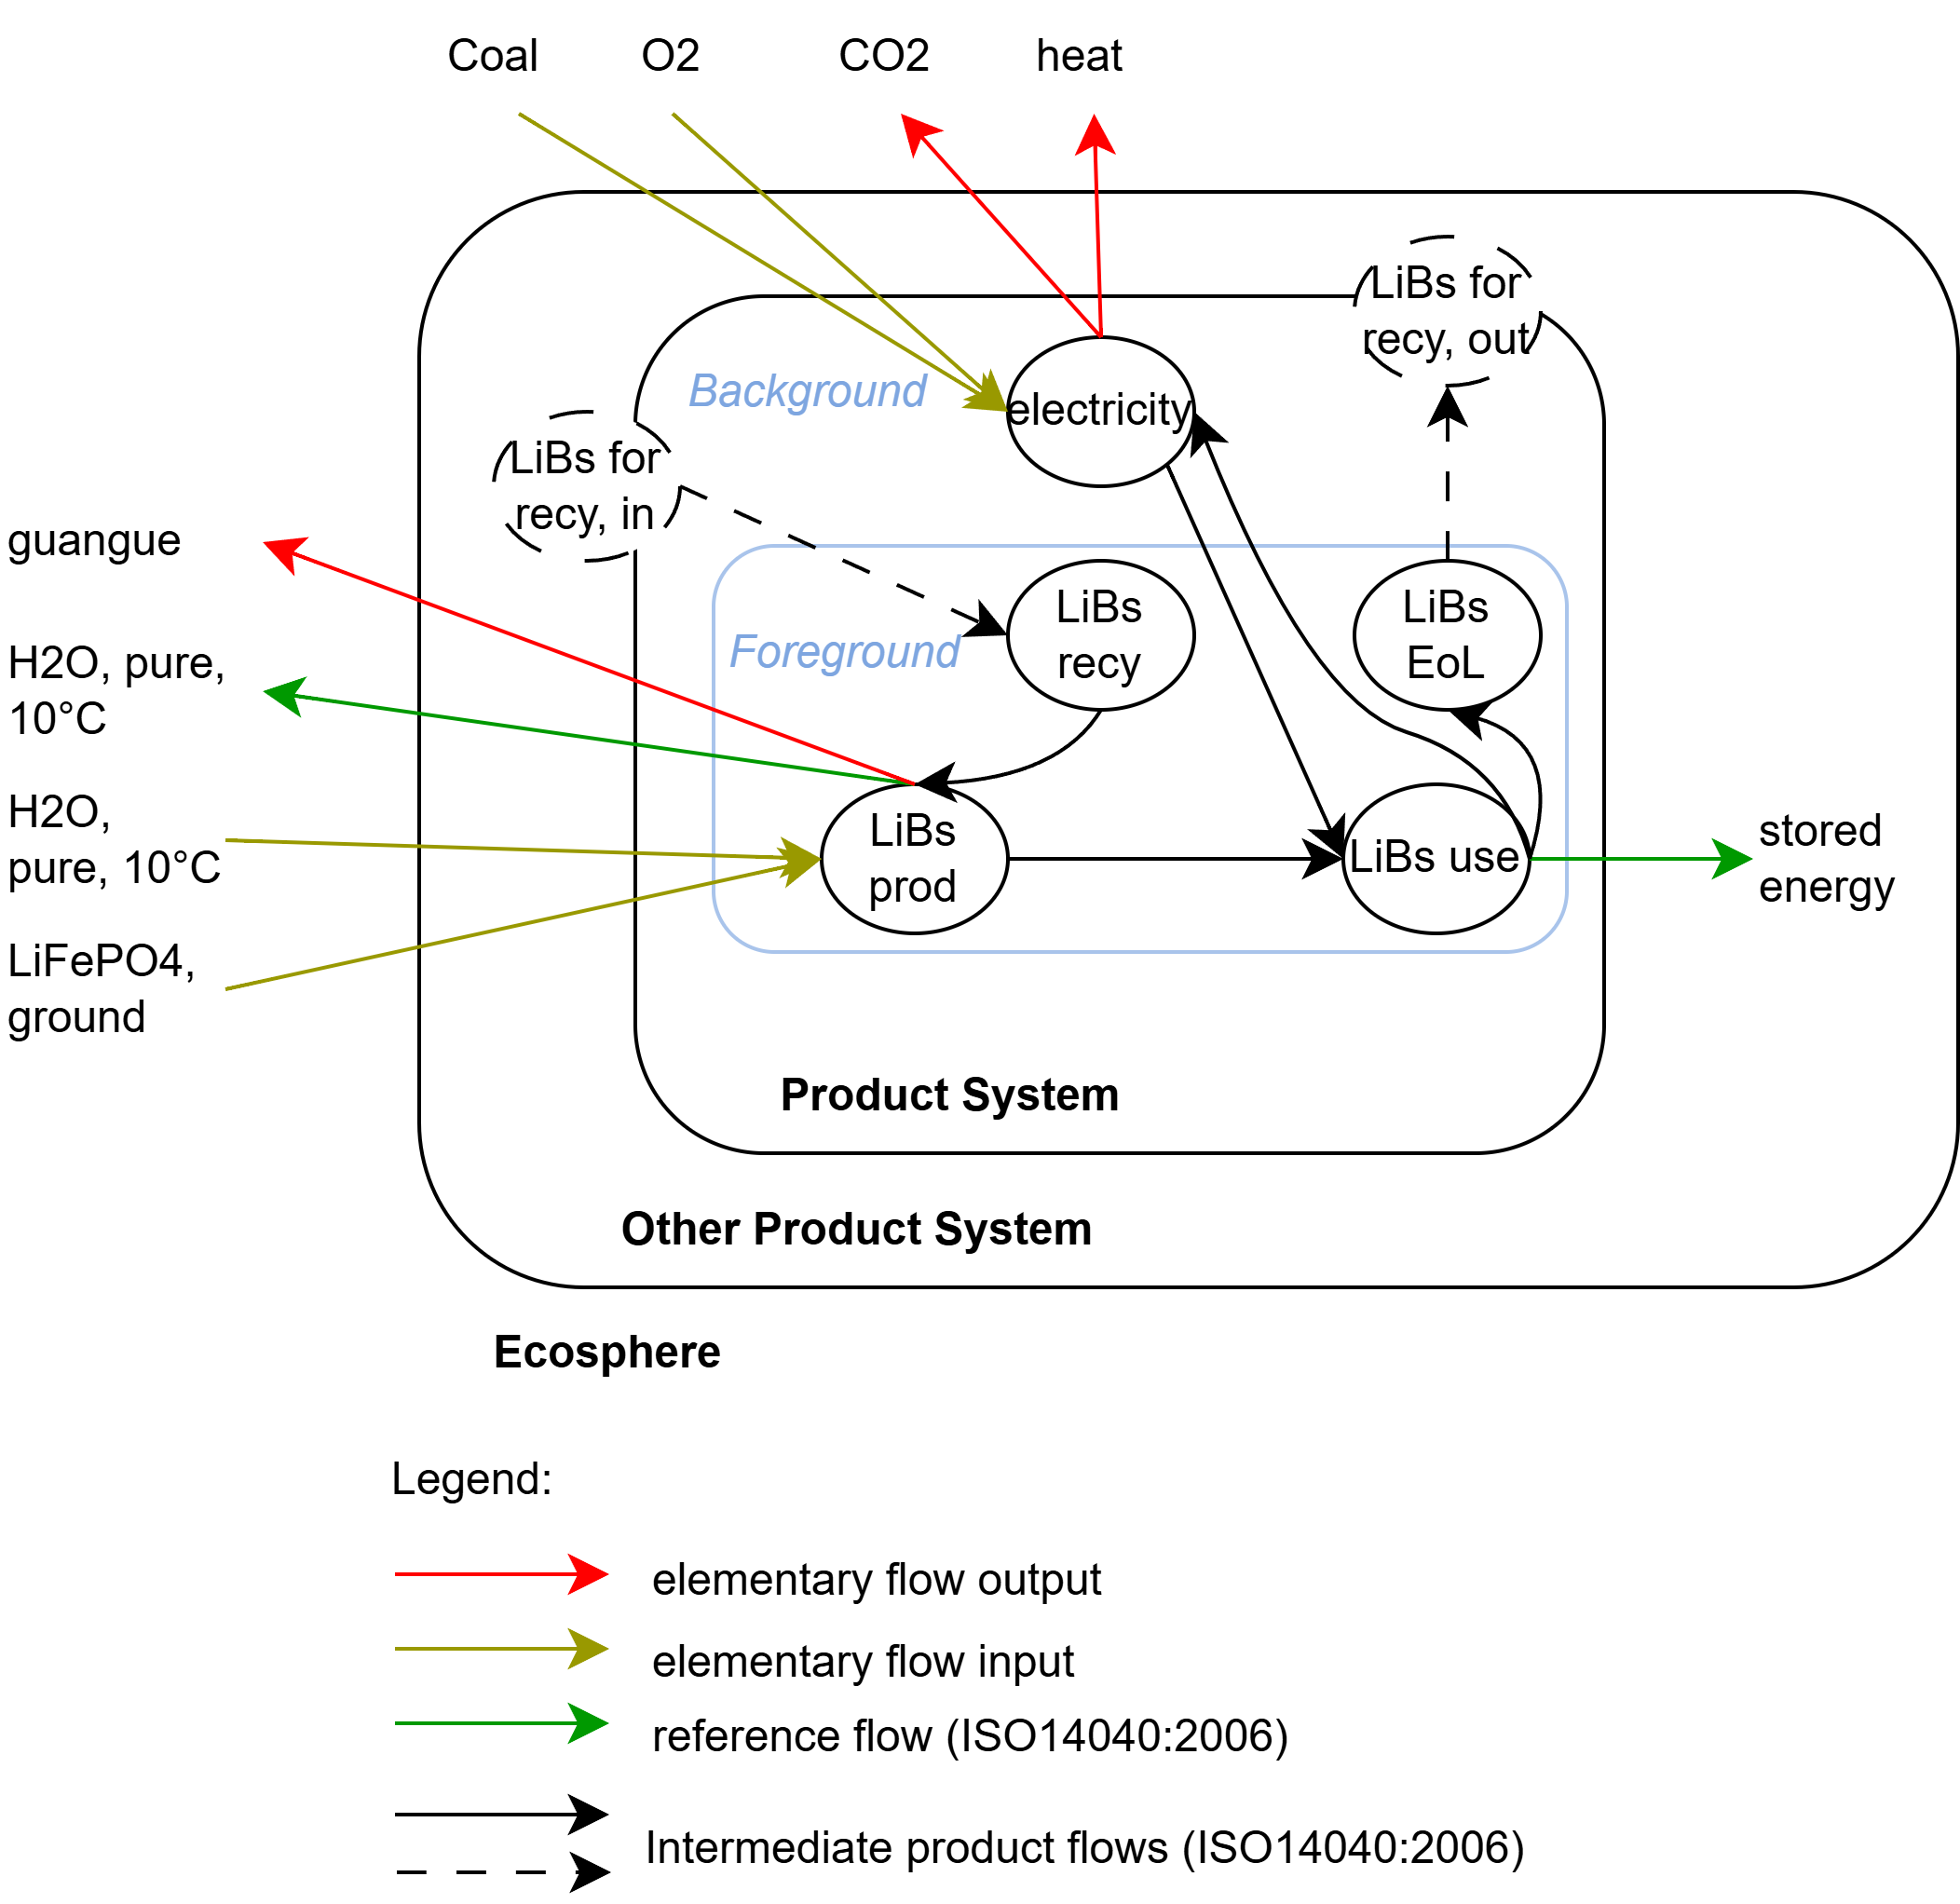

In [11]:
# Diagram 2: LCA Product System Flows
display(Image(filename="conference/thursday/circularity_lci/figures/lca_only.png", width=500))

**Observations 2**: 
- Boundary are changed (electricity activity $\in$ background)
- Flows without information are cut-off but are coming from or to *other product systems*  

**Literature Observation**:  
* 📌 Some sustainability studies apply both circularity indicators and LCA for decision-making support, e.g.:  
=> Based on and **Environmental Footprint (EF) / LCA methods** and **Circularity Indicators**:  

    * [Ruiz de Azua et al. (2026)](https://doi.org/10.1016/j.scitotenv.2026.182167) apply EF 3.1 alongside an adapted **Product Circularity Indicator (PCI)** for power electronic converters.

    * [Nolte et al. (2026)](https://doi.org/10.1016/j.jclepro.2026.148822) combine EF 3.1 with the **Material Circularity Indicator (MCI)** and **ISO 59020** indicators for plastic packaging systems.  

    * Circularity indicators are: calculated **only on direct foreground inputs/outputs** (e.g., physical disassembly weights, direct packaging masses, and local gate-to-gate recycling yields), while LCA models the *entire supply chain* using background inventory databases (e.g., Ecoinvent).  
    ⚠️ Background effects ? ⚠️ 

## ❔ Research Question
> **How to systematically adapt Life Cycle Inventory (LCI) data in order to compute intrinsic circularity indicators across the entire supply chain (foreground + background)?**

##  🎯 Challenges

**C1**: Determine the functionality and non-functionality of the output flows

**C2**: Determine Cut-off flows influence.   
LCA models are not perfect, flows can be ignore because:
- environmental insignificance (ISO14040:2006). ISO 14040 allows omitting flows (EF & PF) considered negligible with respect to:
    - Mass
    - Energy
    - Expected environmental significance
- limited knowledge on LCI stage (Heijungs and Suh (2002) [https://doi.org/10.1007/978-94-015-9900-9]).
- multifunctionality resolving strategy (Heijungs and Suh (2002) [https://doi.org/10.1007/978-94-015-9900-9])

=> **cut-off product flows** must be inventoried as resource flows

**C3**: The circularity indicators are often expressed in either *mass (kg-eq)* or *energy (mj-eq)* units, while LCA flows are not, but have properties and reference properties (ecoinvent, ILCD).

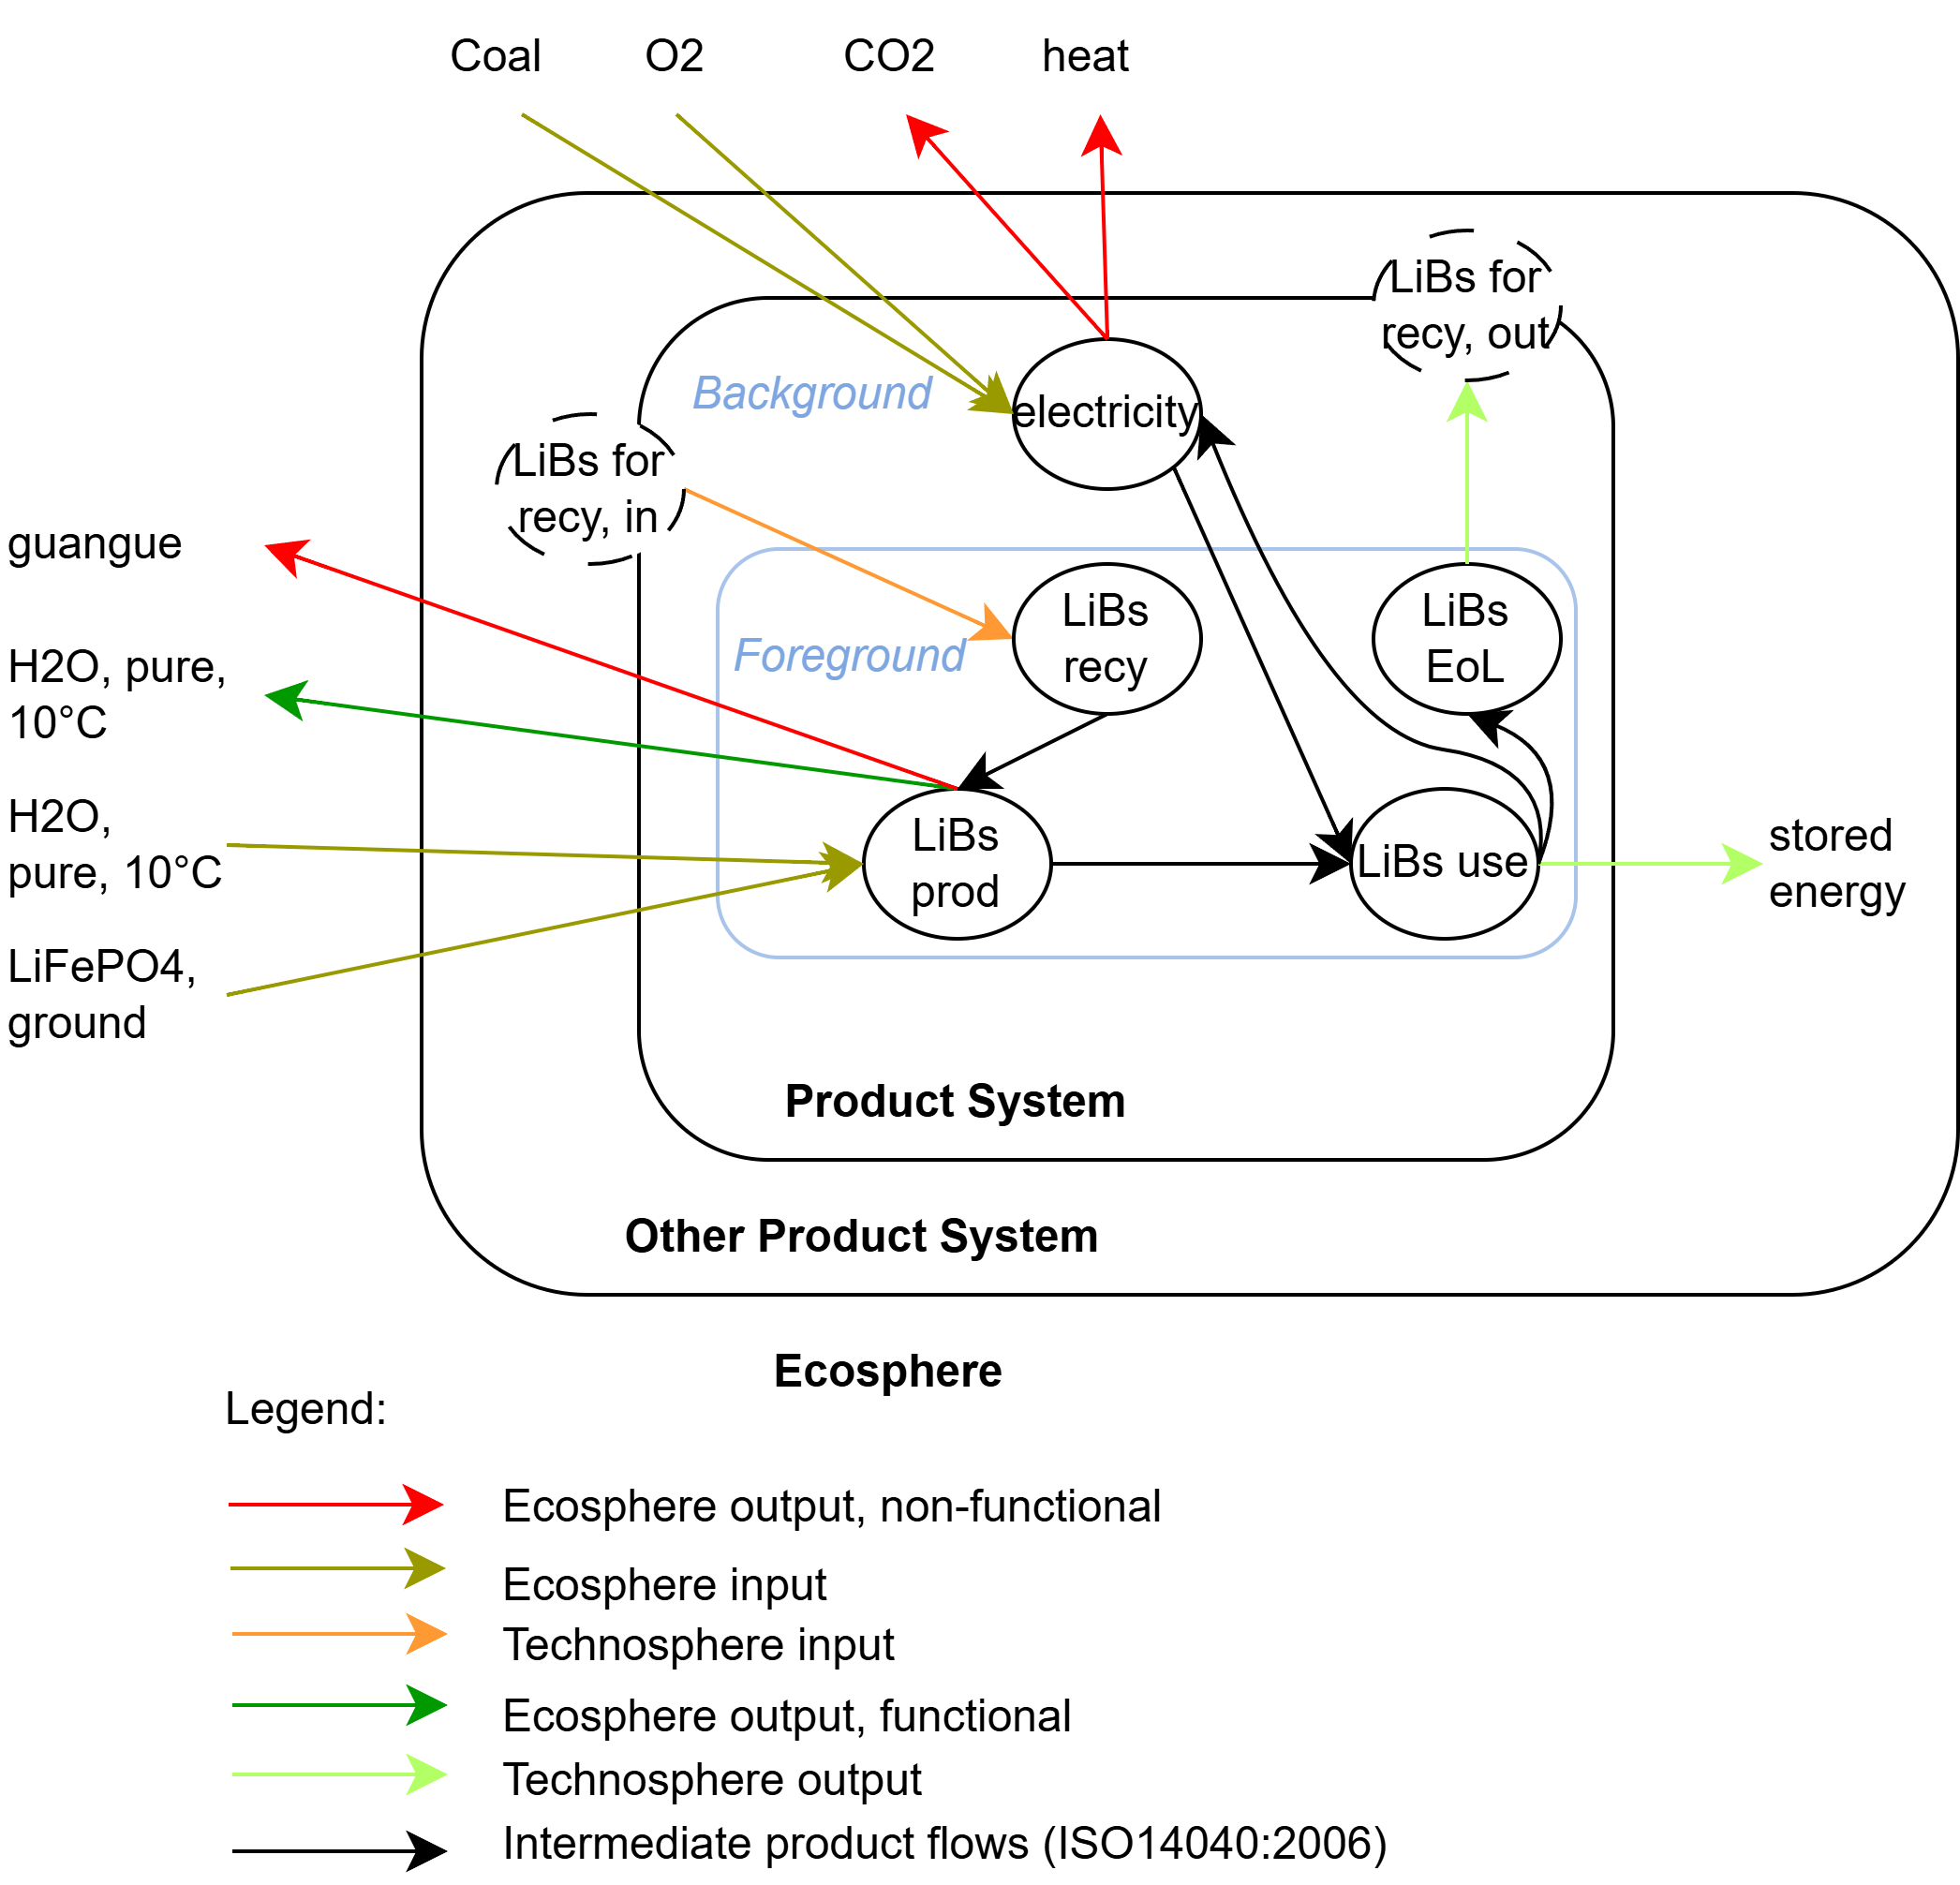

In [12]:
# Diagram 3: Circularity - LCA Mapping Challenges
display(Image(filename="conference/thursday/circularity_lci/figures/circularity-LCA.png", width=500))

## C1: functionality/unfunctionality of output flows

**💡 Solution**: 
* Functional output flows -> \
    i. Reference flows of the functional unit,\
    ii. Cut-off product flows,\
    iii. Elementary flows emissions that do not harmful the environment compartment AND that can still be considered as a viable natural resource.\
* Tagged system, flow's -> *sens*, *functionality*, and *compartment* of origin/destination

## C2: adapt the B matrix

### C2.1: Cut-off Flows tracking

**💡 Solution**: Systematic cut-off flow tracking.

In [6]:
# Class location: bruden_free_analyzer.py

class BurdenFreeAnalyzer:
    """Class enabling the analysis of all the cut-off activities of a Brightway project."""
    
    @staticmethod
    def is_burden_free_activity(activity):
        """Check if an activity is burden-free."""
        if len(list(activity.production())) != 1:
            return False
        if len(list(activity.technosphere())) > 0:
            return False
        if len(list(activity.biosphere())) > 0:
            return False
        return True

This class allows the analysis of all the cut-off activities of a brightway project.

### C2.2: How to get all the resource flows within LCI results

**💡 Solution**: Duplication method.

In [ ]:
# Class location: biosphere_flow_manager.py

class BiosphereFlowManager:
    """Manages the perfect duplication of cut-off activities reference flows within the biosphere matrix."""

    def create_or_get_biosphere_flow(self, activity, production_exchange):
        """Create or reuse a biosphere flow for a burden-free activity.
        This function ensures a biosphere flow exists for the given activity and production exchange.
        It assigns technosphere and location compartments, generates a unique code, and preserves
        relevant information from the activity.
        """
        # Determine name and unit from production_exchange or activity
        ref_name = production_exchange.get('name') or activity.get('name')
        ref_unit = production_exchange.get('unit') or activity.get('unit')
        
        # Define compartments
        compartment = 'technosphere'
        subcomp = activity.get('location', 'Unknown')
        
        # Check if the flow already exists in the biosphere database
        for flow in self.biosphere_db: # type: ignore
            if (flow.get('name') == ref_name and
                flow.get('unit') == ref_unit and
                flow.get('categories') == (compartment, subcomp)):
                return flow.key, False
                
        # Create a new flow if it doesn't exist
        new_code = f"{activity.key}_BF_{bw2data_utils.random_string(5)}" # type: ignore
        new_flow = self.biosphere_db.new_activity(code=new_code) # type: ignore
        new_flow.update({
            'database': self.biosphere_db_name, # type: ignore
            'code': new_code,
            'name': ref_name,
            'unit': ref_unit,
            'categories': (compartment, subcomp),
            'type': 'technosphere'
        })
        new_flow.save()
        return new_flow.key, True

This class allows the perfect duplication of the cut-off activities reference flows, within the biosphere matrix.

However the full coverage of the material content and energy content required for circularity indicators is yet no respected.

## C3: material and energy properties retrieval

**How to get all the resource flows material and energy content to derive holistic circularity indicators on a systematic way?**

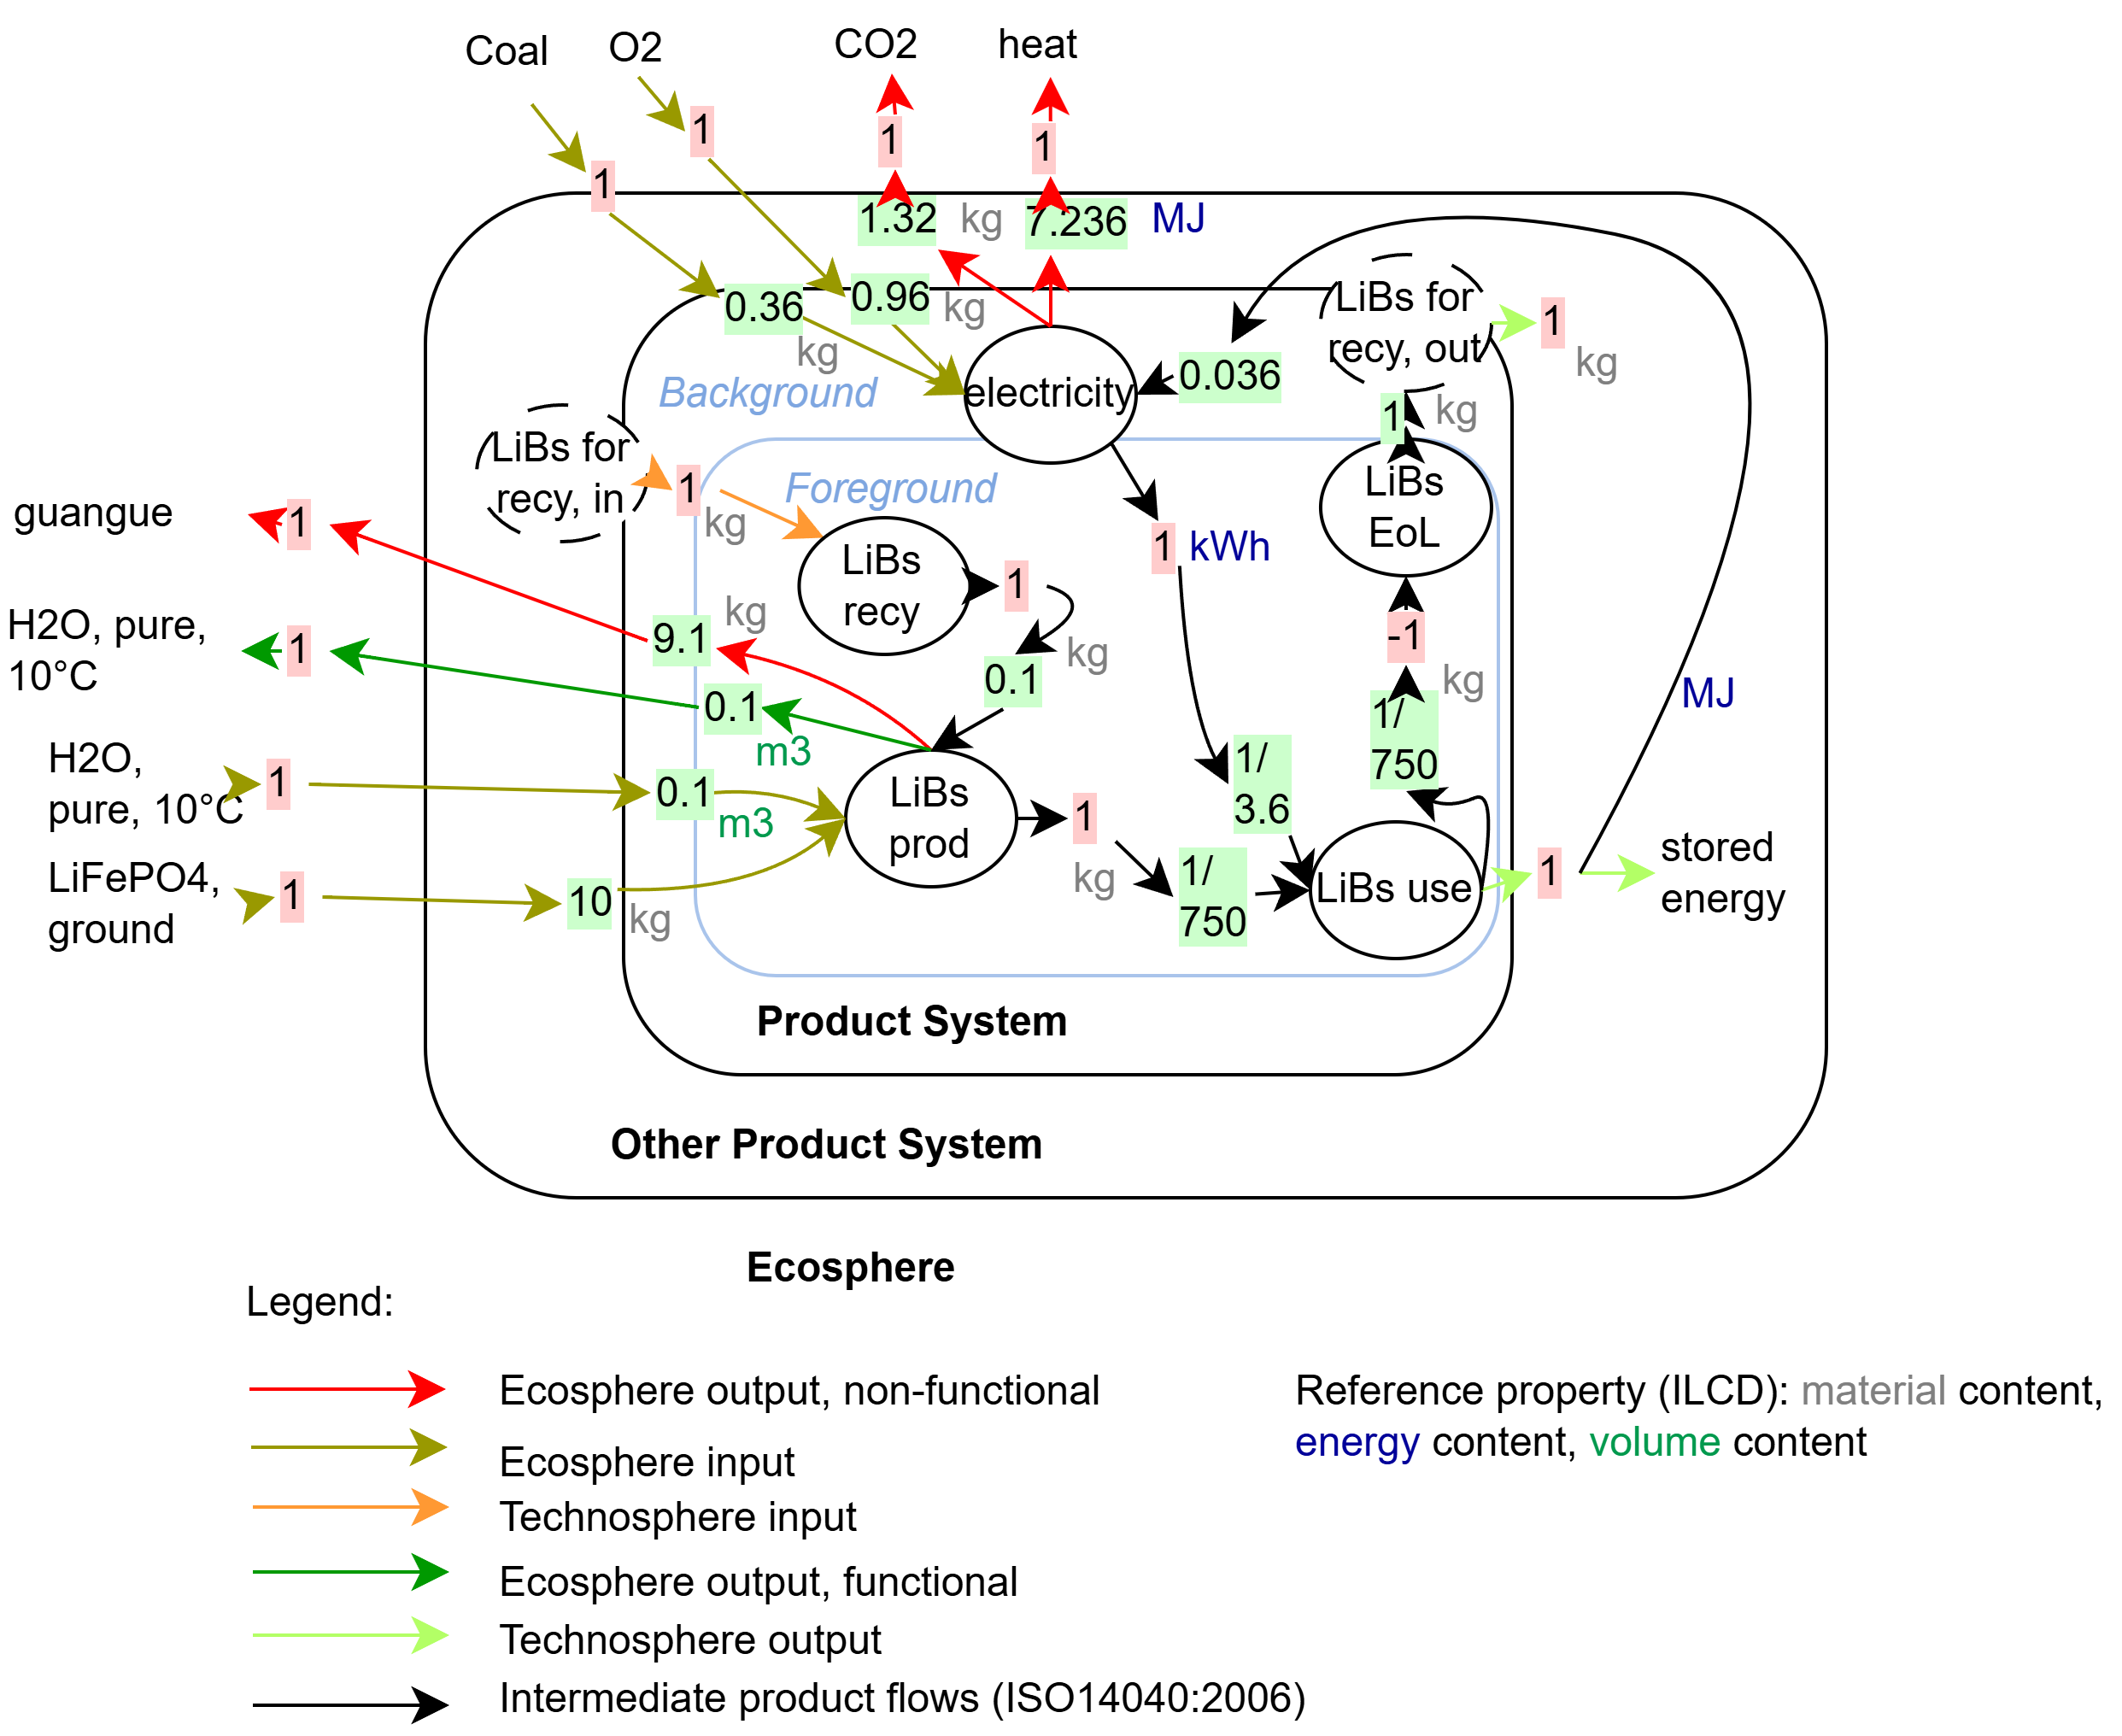

In [13]:
# Diagram 4: Circularity - LCA with LCI Mapping
display(Image(filename="conference/thursday/circularity_lci/figures/circularity-LCA_+LCImak.png", width=500))

* Various strategies:
📖 De Wachter et al. (2026) [https://doi.org/10.1007/s44498-026-00068-2] used e.g., kg units, for materials mass content ✅, CAS numbers ✅, ...
Here:
Presently, hierarchical approach:
- if unit is in kg for mass content, MJ for energy content: no convertion factors
- for resource flows with CED non-renewable CFs: use the CFs as convertion factors. 
- ultimatly: check if a property traduces energy and material content (e.g., using ecoinvent nomenclature for energy: "heating value, net" or "energy content", and for mass: "wet mass")

In [9]:
def build_combined_lookup(self):
    """
    Build combined lookup for both mass and energy properties in one pass.
    """
    biosphere_db = bd.Database(self.biosphere_db_name) # type: ignore
    techno_to_bio_map = {}
    for flow in biosphere_db:
        categories = flow.get('categories', ())
        if categories and categories[0] == 'technosphere' and len(categories) > 1:
            location = categories[1]
            key = (flow.get('name', ''), location)
            techno_to_bio_map[key] = (flow.get('name', ''), categories)
    mass_lookup = {}
    energy_lookup = {}
    water_lookup = {}
    dry_mass_lookup = {}
    db = bd.Database(self.technosphere_db_name) # type: ignore
    for act in db: # ⚠️ we are recovering the exchange properties from the tech db !
        for exc in act.exchanges():
            properties = exc.get('properties', {})
            wet_mass = properties.get('wet mass', {}) # total mass
            dry_mass = properties.get('dry mass', {}) # dry mass (without water molecules)
            water_content = properties.get('water content', {}) # water content
            energy_content = properties.get('energy content', {})
            heating_value = properties.get('heating value, net', {})
            lhv_MJperkg = properties.get('lower heating value MJ per kg', {})
            gross_energy_per_dry_mass = properties.get('gross energy, feed per kg of dry mass', {})
            # mass
            has_wet_mass = wet_mass and wet_mass.get('amount') is not None
            has_water_content = water_content and water_content.get('amount') is not None
            has_dry_mass = dry_mass and dry_mass.get('amount') is not None
            # energy
            has_energy_content = energy_content and energy_content.get('amount') is not None
            has_heating_value = heating_value and heating_value.get('amount') is not None
            has_specific_lhv = lhv_MJperkg and lhv_MJperkg.get('amount') is not None # in MJ per kg
            has_GEperdrymass = gross_energy_per_dry_mass and gross_energy_per_dry_mass.get('amount') is not None
            ...

## Inventory Calculation with `bw2calc`

The inventory can then be run with bw2calc:

In [10]:
@staticmethod
def get_inventory_flows(setup_name=None, functional_unit=None):
    """
    Retrieve inventory flows from either a calculation setup or a functional unit.
    Parameters:
    -----------
    setup_name : str, optional
        Name of the calculation setup in Brightway2
    functional_unit : dict, optional
        Direct functional unit like {process.key: 1}
    Returns:
    --------
    pd.DataFrame: Inventory flows
    """
    all_flows = []
    # Get functional units from either setup or direct input
    if setup_name:
        setup = bd.calculation_setups[setup_name] # type: ignore
        functional_units = setup['inv']
    elif functional_unit:
        functional_units = [functional_unit]
    else:
        raise ValueError("Either setup_name or functional_unit must be provided")
    for fu_dict in functional_units:
        lca = bc.LCA(fu_dict) # type: ignore
        lca.lci()
        ...

which yield the basis to compute the circularity indicators:

# Simple example
based on the previous simple flowsheet

In [4]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import glob

import bw2data as bd
import bw2calc as bc

# !pip install circularitylci
import circularitylci as clci # type: ignore

## LCI: collection

In [3]:
# ============================================================================
# PART 1: MODEL PARAMETERS
# ============================================================================

# Functional unit
fu_amount = 750  # 750 MJ of stored energy

# 🎯
eff_elec_prod_lower = 0.33 # current efficiency 
eff_elec_prod_higher = 0.60 # carnot efficiency, 800K
eff_elec_prod = eff_elec_prod_lower 

if eff_elec_prod == eff_elec_prod_lower:
    param_csv = "e-low"
else:
    param_csv = "e-high"

eff_LiBs_prod = 0.9 # can be lower

# Coal-based electricity parameters
M_C = 12 * 0.001       # kg/mol
M_O = 16 * 0.001       # kg/mol
LHV_C = 30             # MJ/kg

# 🎯
reuse_LiBs_in_grid_MJ_low = 0.01
reuse_LiBs_in_grid_MJ_high = 0.1
reuse_battery_in_grid_MJ = reuse_LiBs_in_grid_MJ_high

if reuse_battery_in_grid_MJ == reuse_LiBs_in_grid_MJ_low:
    param_csv += "_r-low"
else:
    param_csv += "_r-high"

# Coal input and heat losses required to produce the electricity
Coal_input = (
    (1 - reuse_battery_in_grid_MJ)
    / eff_elec_prod
    / LHV_C
)

Heat_losses = (
    (1 - reuse_battery_in_grid_MJ)
    * (1 - eff_elec_prod)
    / eff_elec_prod
)

# 🎯
# LiBs production parameters
ore_grade_high = 0.2 # x20
ore_grade_low = 0.01

ore_grade = ore_grade_low

if ore_grade == ore_grade_low:  
    param_csv += "_og-low"
else:
    param_csv += "_og-high"

# 🎯
LiBs_recy_input_low = 0.1
LiBs_recy_input_high = 0.8
LiBs_recy_input = LiBs_recy_input_low
if LiBs_recy_input == LiBs_recy_input_low:
    param_csv += "_rci-low"
else:
    param_csv += "_rci-high"

# Primary ore required to produce 1 kg LiBs
LiBs_ore_input = (
    (1 - LiBs_recy_input)
    / ore_grade
    / eff_LiBs_prod
)

# Gangue associated with primary LiBs production
guangue_dissi_prod = (
    (1 - ore_grade)
    * LiBs_ore_input
)

# Total LiBs produced before accounting for dissipation
LiBs_tot_prod = (
    LiBs_ore_input * ore_grade
    + LiBs_recy_input
)

# LiBs dissipated
LiBs_dissi = LiBs_tot_prod - 1

# Water requirement
water_cubic_meter_amount = 0.01

# Total dissipated gangue + LiBs
guangue_dissi_tot = (
    guangue_dissi_prod
    + LiBs_dissi
)

# Set up project
project_name = "libs_circularity_brightcon"
bd.projects.set_current(project_name)

excluded_flows = [
    "BOD5, Biological Oxygen Demand",
    "COD, Chemical Oxygen Demand",
    "DOC, Dissolved Organic Carbon",
    "TOC, Total Organic Carbon"
]

# valuable compartment for water flows, see function file for usability
valuable_water_compartments = ['ground-', 'surface water'] # for water flows
exclude_water = False  # Set to False if water flows are included # should be based on wet_mass or dry_mass => check dry_mass working
mass_strategy = "full_mass"      # options: "full_mass", "water_mass", "dry_mass"
energy_strategy = "full_energy"

# fit with functions.py compliancies
database_provider = "None"  
database_version = "None"
database_systemmodel = "cutoff"
ecospold_folder = None


# ============================================================================
# PART 1: CLEAN PROJECT AND METHODS (FIXED)
# ============================================================================

# FIRST: Delete all LCIA methods (before deleting databases)
# This prevents Brightway from trying to validate methods that reference deleted databases
if hasattr(bd, 'methods'):
    for method_name in list(bd.methods):
        try:
            del bd.methods[method_name]
        except:
            pass  # Some methods might already be gone

# SECOND: Delete all databases
for db_name in list(bd.databases):
    try:
        del bd.databases[db_name]
    except:
        pass

# THIRD: Delete the project
if project_name in bd.projects:
    bd.projects.delete_project(project_name, delete_dir=True)

# FOURTH: Create fresh project
bd.projects.set_current(project_name)


# ============================================================================
# PART 2: CREATE DATABASES
# ============================================================================

technosphere_db_name = (
    f"{database_provider}-{database_version}-{database_systemmodel}"
)

biosphere_db_name = (
    f"{database_provider}-{database_version}-biosphere"
)

# Delete existing databases
if technosphere_db_name in bd.databases:
    del bd.databases[technosphere_db_name]

if biosphere_db_name in bd.databases:
    del bd.databases[biosphere_db_name]

# Create empty databases
bd.Database(technosphere_db_name).write({})
bd.Database(biosphere_db_name).write({})

technosphere_db = bd.Database(technosphere_db_name)
biosphere_db = bd.Database(biosphere_db_name)


# ============================================================================
# PART 3: CREATE BIOSPHERE FLOWS
# ============================================================================

biosphere_flows = [

    # ------------------------------------------------------------------------
    # Emissions
    # ------------------------------------------------------------------------

    (
        'Guangue',
        'kilogram',
        ('soil', 'unspecified')
    ),

    (
        'Heat',
        'megajoule',
        ('air', 'unspecified')
    ),

    (
        'Carbon dioxide',
        'kilogram',
        ('air', 'unspecified')
    ),

    (
        'Water',
        'cubic meter',
        ('water', 'ground-water')
    ),

    # ------------------------------------------------------------------------
    # Resources
    # ------------------------------------------------------------------------

    (
        'Coal, brown',
        'kilogram',
        ('natural resource', 'in ground')
    ),

    (
        'Dioxygen',
        'kilogram',
        ('natural resource', 'in air')
    ),

    (
        'LiFePO4 magic ore',
        'kilogram',
        ('natural resource', 'in ground')
    ),

    (
        'Water',
        'cubic meter',
        ('natural resource', 'in ground')
    ),
]


for name, unit, categories in biosphere_flows:

    code = f"{name}_{categories[0]}_{categories[1]}"

    biosphere_db.new_node(
        code=code,
        name=name,
        unit=unit,
        categories=categories,
        type=bd.labels.biosphere_node_default,
    ).save()


# ============================================================================
# PART 4: CREATE TECHNOSPHERE ACTIVITIES
# ============================================================================

# ---------------------------------------------------------------------------
# 1. LiBs use
# ---------------------------------------------------------------------------

libs_use = technosphere_db.new_node(
    code='libs_use',
    name='LiBs use',
    unit='megajoule',
    location='FR',
    type=bd.labels.process_node_default,
)
libs_use.save()
libs_use['reference product'] = "stored electricity"
libs_use.save()


# ---------------------------------------------------------------------------
# 2. LiBs input EoL cut-off
# ---------------------------------------------------------------------------

libs_inputs_eol_cutoff = technosphere_db.new_node(
    code='libs_inputs_eol_cutoff',
    name='LiBs Inputs EoL (cut-off)',
    unit='kilogram',
    location='FR',
    type=bd.labels.process_node_default,
)
libs_inputs_eol_cutoff.save()


# ---------------------------------------------------------------------------
# 3. LiBs output EoL cut-off
# ---------------------------------------------------------------------------

libs_outputs_eol_cutoff = technosphere_db.new_node(
    code='libs_outputs_eol_cutoff',
    name='LiBs Outputs EoL (cut-off)',
    unit='kilogram',
    location='FR',
    type=bd.labels.process_node_default,
)
libs_outputs_eol_cutoff.save()


# ---------------------------------------------------------------------------
# 4. Electricity production
# ---------------------------------------------------------------------------

electricity = technosphere_db.new_node(
    code='electricity_production',
    name='Electricity production',
    unit='kilowatt hour',
    location='FR',
    type=bd.labels.process_node_default,
)
electricity.save()


# ---------------------------------------------------------------------------
# 5. LiBs production
# ---------------------------------------------------------------------------

libs_production = technosphere_db.new_node(
    code='libs_production',
    name='LiBs production',
    unit='kilogram',
    location='FR',
    type=bd.labels.process_node_default,
)
libs_production.save()


# ---------------------------------------------------------------------------
# 6. LiBs EoL treatment
# ---------------------------------------------------------------------------

libs_eol_treatment = technosphere_db.new_node(
    code='libs_eol_treatment',
    name='LiBs EoL Treatment',
    unit='kilogram',
    location='FR',
    type=bd.labels.process_node_default,
)
libs_eol_treatment.save()


# ============================================================================
# PART 5: BIOSPHERE FLOW HELPER
# ============================================================================

def get_flow(name, categories):

    return next(
        flow
        for flow in biosphere_db
        if (
            flow['name'] == name
            and flow['categories'] == categories
        )
    )


# Get biosphere flows

guangue = get_flow(
    'Guangue',
    ('soil', 'unspecified')
)

heat_em = get_flow(
    'Heat',
    ('air', 'unspecified')
)

coal = get_flow(
    'Coal, brown',
    ('natural resource', 'in ground')
)

co2 = get_flow(
    'Carbon dioxide',
    ('air', 'unspecified')
)

water_resource = get_flow(
    'Water',
    ('natural resource', 'in ground')
)

water_em = get_flow(
    'Water',
    ('water', 'ground-water')
)

lifepo4_ore = get_flow(
    'LiFePO4 magic ore',
    ('natural resource', 'in ground')
)

dioxygen = get_flow(
    'Dioxygen',
    ('natural resource', 'in air')
)


# ============================================================================
# PART 6: CREATE TECHNOSPHERE AND BIOSPHERE EXCHANGES
# ============================================================================


# ============================================================================
# 6.1 LiBs USE
# ============================================================================

# Reference product:
# 1 MJ of stored LiBs energy
libs_use.new_edge(
    input=libs_use,
    amount=1,
    type=bd.labels.production_edge_default,
).save()


# LiBs required:
# 1 kg LiBs / 750 MJ
libs_use.new_edge(
    input=libs_production,
    amount=1 / 750,
    type=bd.labels.consumption_edge_default,
).save()


# Electricity required:
# 1 MJ = 1/3.6 kWh
libs_use.new_edge(
    input=electricity,
    amount=1 / 3.6,
    type=bd.labels.consumption_edge_default,
).save()


# EoL treatment associated with the LiBs use
libs_use.new_edge(
    input=libs_eol_treatment,
    amount=1 / 750,
    type=bd.labels.consumption_edge_default,
).save()


# ============================================================================
# 6.2 ELECTRICITY PRODUCTION
# ============================================================================

# Reference product:
# 1 kWh electricity
electricity.new_edge(
    input=electricity,
    amount=1,
    type=bd.labels.production_edge_default,
).save()


# Coal resource
#
# Coal_input is expressed per MJ of useful electricity.
# The electricity process is expressed per kWh.
#
# Therefore:
# kg coal / kWh = Coal_input * 3.6
#
# However, because the process is connected to the LiBs-use process
# through 1/3.6 kWh per MJ, keeping the exchange as Coal_input/3.6
# would describe a different scaling.
#
# To reproduce the stated electricity-process model directly per kWh:
electricity.new_edge(
    input=coal,
    amount=Coal_input * 3.6,
    type=bd.labels.biosphere_edge_default,
).save()


# O2 resource
electricity.new_edge(
    input=dioxygen,
    amount=(
        Coal_input
        / M_C
        * (2 * M_O)
        * 3.6
    ),
    type=bd.labels.biosphere_edge_default,
).save()


# CO2 emission
electricity.new_edge(
    input=co2,
    amount=(
        Coal_input
        / M_C
        * (2 * M_O + M_C)
        * 3.6
    ),
    type=bd.labels.biosphere_edge_default,
).save()


# Heat losses
electricity.new_edge(
    input=heat_em,
    amount=Heat_losses * 3.6,
    type=bd.labels.biosphere_edge_default,
).save()


# Electricity generated from stored LiBs
electricity.new_edge(
    input=libs_use,
    amount=reuse_battery_in_grid_MJ * 3.6,
    type=bd.labels.consumption_edge_default,
).save()


# ============================================================================
# 6.3 LiBs OUTPUT EoL CUT-OFF
# ============================================================================

# EoL LiBs output product
libs_outputs_eol_cutoff.new_edge(
    input=libs_outputs_eol_cutoff,
    amount=1,
    type=bd.labels.production_edge_default,
).save()


# ============================================================================
# 6.4 LiBs INPUT EoL CUT-OFF
# ============================================================================

# Cut-off LiBs available to the product system
libs_inputs_eol_cutoff.new_edge(
    input=libs_inputs_eol_cutoff,
    amount=1,
    type=bd.labels.production_edge_default,
).save()


# ============================================================================
# 6.5 LiBs PRODUCTION
# ============================================================================

# Reference product:
# 1 kg LiBs
libs_production.new_edge(
    input=libs_production,
    amount=1,
    type=bd.labels.production_edge_default,
).save()


# Water resource
libs_production.new_edge(
    input=water_resource,
    amount=water_cubic_meter_amount,
    type=bd.labels.biosphere_edge_default,
).save()


# Water emission
libs_production.new_edge(
    input=water_em,
    amount=water_cubic_meter_amount,
    type=bd.labels.biosphere_edge_default,
).save()


# Primary LiFePO4 ore resource
libs_production.new_edge(
    input=lifepo4_ore,
    amount=LiBs_ore_input,
    type=bd.labels.biosphere_edge_default,
).save()


# Recycled LiBs input
libs_production.new_edge(
    input=libs_inputs_eol_cutoff,
    amount=LiBs_recy_input,
    type=bd.labels.consumption_edge_default,
).save()


# Gangue dissipation
libs_production.new_edge(
    input=guangue,
    amount=guangue_dissi_tot,
    type=bd.labels.biosphere_edge_default,
).save()


# ============================================================================
# 6.6 LiBs EoL TREATMENT
# ============================================================================

# Waste treatment process.
#
# A negative production exchange is deliberately retained here because
# this is the representation used in your A1 matrix:
#
# A1 row 5, column 5 = -1
#
libs_eol_treatment.new_edge(
    input=libs_eol_treatment,
    amount=-1,
    type=bd.labels.production_edge_default,
).save()


# EoL LiBs output from treatment
libs_eol_treatment.new_edge(
    input=libs_outputs_eol_cutoff,
    amount=1,
    type=bd.labels.consumption_edge_default,
).save()


# ============================================================================
# PART 7: ADD EXCHANGE PROPERTIES
# ============================================================================

# ---------------------------------------------------------------------------
# Coal
# ---------------------------------------------------------------------------

coal_exc = next(
    (
        exc
        for exc in electricity.exchanges()
        if exc.input == coal
    ),
    None
)

if coal_exc:

    coal_exc['properties'] = {
        'wet mass': {
            'amount': 1.0,
            'unit': 'kilogram'
        },
        'energy content': {
            'amount': LHV_C,
            'unit': 'megajoule'
        }
    }

    coal_exc.save()



# ---------------------------------------------------------------------------
# Water resource
# ---------------------------------------------------------------------------

water_resource_exc = next(
    (
        exc
        for exc in libs_production.exchanges()
        if exc.input == water_resource
    ),
    None
)

if water_resource_exc:

    water_resource_exc['properties'] = {
        'wet mass': {
            'amount': 1000,
            'unit': 'kilogram'
        },
        'water content': {
            'amount': 1.0,
            'unit': 'kilogram/kilogram'
        }
    }

    water_resource_exc.save()


# ---------------------------------------------------------------------------
# Water emission
# ---------------------------------------------------------------------------

water_em_exc = next(
    (
        exc
        for exc in libs_production.exchanges()
        if exc.input == water_em
    ),
    None
)

if water_em_exc:

    water_em_exc['properties'] = {
        'wet mass': {
            'amount': 1000,
            'unit': 'kilogram'
        },
        'water content': {
            'amount': 1.0,
            'unit': 'kilogram/kilogram'
        }
    }

    water_em_exc.save()


print("Database created successfully!")

Database created successfully!


## circularity LCI results

In [ ]:
import circularitylci as clci # type: ignore
import bw2data as bd
import bw2calc as bc

# Step 1: Setup and identify burden-free activities
bf_analyzer = clci.BurdenFreeAnalyzer(
    project_name=project_name,
    database_provider=database_provider,
    ecospold_folder=ecospold_folder,
    technosphere_db_name=technosphere_db_name,
    database_version=database_version,
    database_systemmodel=database_systemmodel
)
bf_analyzer.setup_project()  # Ensure project is set up
burden_free_activities = bf_analyzer.analyze_all_databases()  # Returns dict of {db_name: [activities]}

# Step 2: Create biosphere flows for burden-free activities
bf_manager = clci.BiosphereFlowManager(biosphere_db_name)
bf_manager.process(burden_free_activities)  # Duplicates cut-off flows to biosphere

def find_processes_by_name(name_part, loc="", ref_product=""):
    """Find processes matching name, location, and reference product."""
    matches = []

    db = bd.Database(technosphere_db_name)

    for act in db:
        name = str(act.get("name", ""))
        location_value = str(act.get("location", ""))

        activity_ref_product = act.get("reference product")

        if not activity_ref_product:
            production_exchanges = list(act.production())
            if production_exchanges:
                activity_ref_product = (
                    production_exchanges[0].get("name")
                    or act.get("name", "")
                )

        activity_ref_product = str(activity_ref_product or "")

        if (
            name_part.lower() in name.lower()
            and loc.lower() in location_value.lower()
            and ref_product.lower() in activity_ref_product.lower()
        ):
            matches.append(act)

    return matches

# process_name = "banana production" 
# location = "RoW"
# reference_product = "banana"

process_name = "LiBs use" 
location = "FR" 
reference_product = "" 

target_processes = find_processes_by_name(
    process_name,
    location,
    reference_product,
)

if not target_processes:
    raise ValueError("No matching LiBs use activity was found.")

fu = {target_processes[0].key: fu_amount}

# Step 4: Compute circularity
circ_calc = clci.circularitycalculator(
    project_name=project_name,
    excluded_flows=excluded_flows,
    valuable_water_compartments=valuable_water_compartments,
    exclude_water=exclude_water,
    technosphere_db_name=technosphere_db_name,
    biosphere_db_name=biosphere_db_name,
    mass_strategy=mass_strategy,
    energy_strategy=energy_strategy
)

# Compute circularity directly with functional unit (no setup needed!)
try:
    fu = {target_processes[0].key: fu_amount}
    result_df, inefficiency, efficiency, detailed_flows = circ_calc.compute_circularity_efficiency_variables(
        functional_unit=fu,
        save_csv=False
    )
    
    print("\n" + "="*50)
    print("CIRCULARITY RESULTS")
    print("="*50)
    
    if result_df is not None:
        display(result_df)
        output_dir = f"results/csv/{project_name}"
        os.makedirs(output_dir, exist_ok=True)
        result_df.to_csv(f"{output_dir}/circularity_results_for_{param_csv}.csv", index=True)
    else:
        print("No results returned")
        
except Exception as e:
    print(f"Error computing circularity: {e}")
    import traceback
    traceback.print_exc()


16:04:04+0200 [info     ] Successfully switch activity dataset to database `None-None-biosphere`
16:04:04+0200 [info     ] Successfully switched activity dataset to new code `('None-None-cutoff', 'libs_outputs_eol_cutoff')_BF_9Cqjt`
16:04:04+0200 [info     ] Successfully switch activity dataset to database `None-None-biosphere`
16:04:04+0200 [info     ] Successfully switched activity dataset to new code `('None-None-cutoff', 'libs_inputs_eol_cutoff')_BF_pdh6d`

CIRCULARITY RESULTS


,Natural Resources,Technosphere Inputs,Recycled Outputs,Cleaned Emissions,Waste Emissions,Total Input (V+Ri),Total functional (Er+Rr),inefficiency (η-),efficiency (η+)
kilogram,400.000013,0.111111,1.111111,11.111111,387.888914,400.111124,12.222222,0.969453,0.030547
cubic meter,0.011111,0.000000,0.000000,0.011111,0.000000,0.011111,0.011111,0.000000,1.000000
megajoule,2272.727305,0.000000,750.000000,0.000000,1522.727343,2272.727305,750.000000,0.670000,0.330000


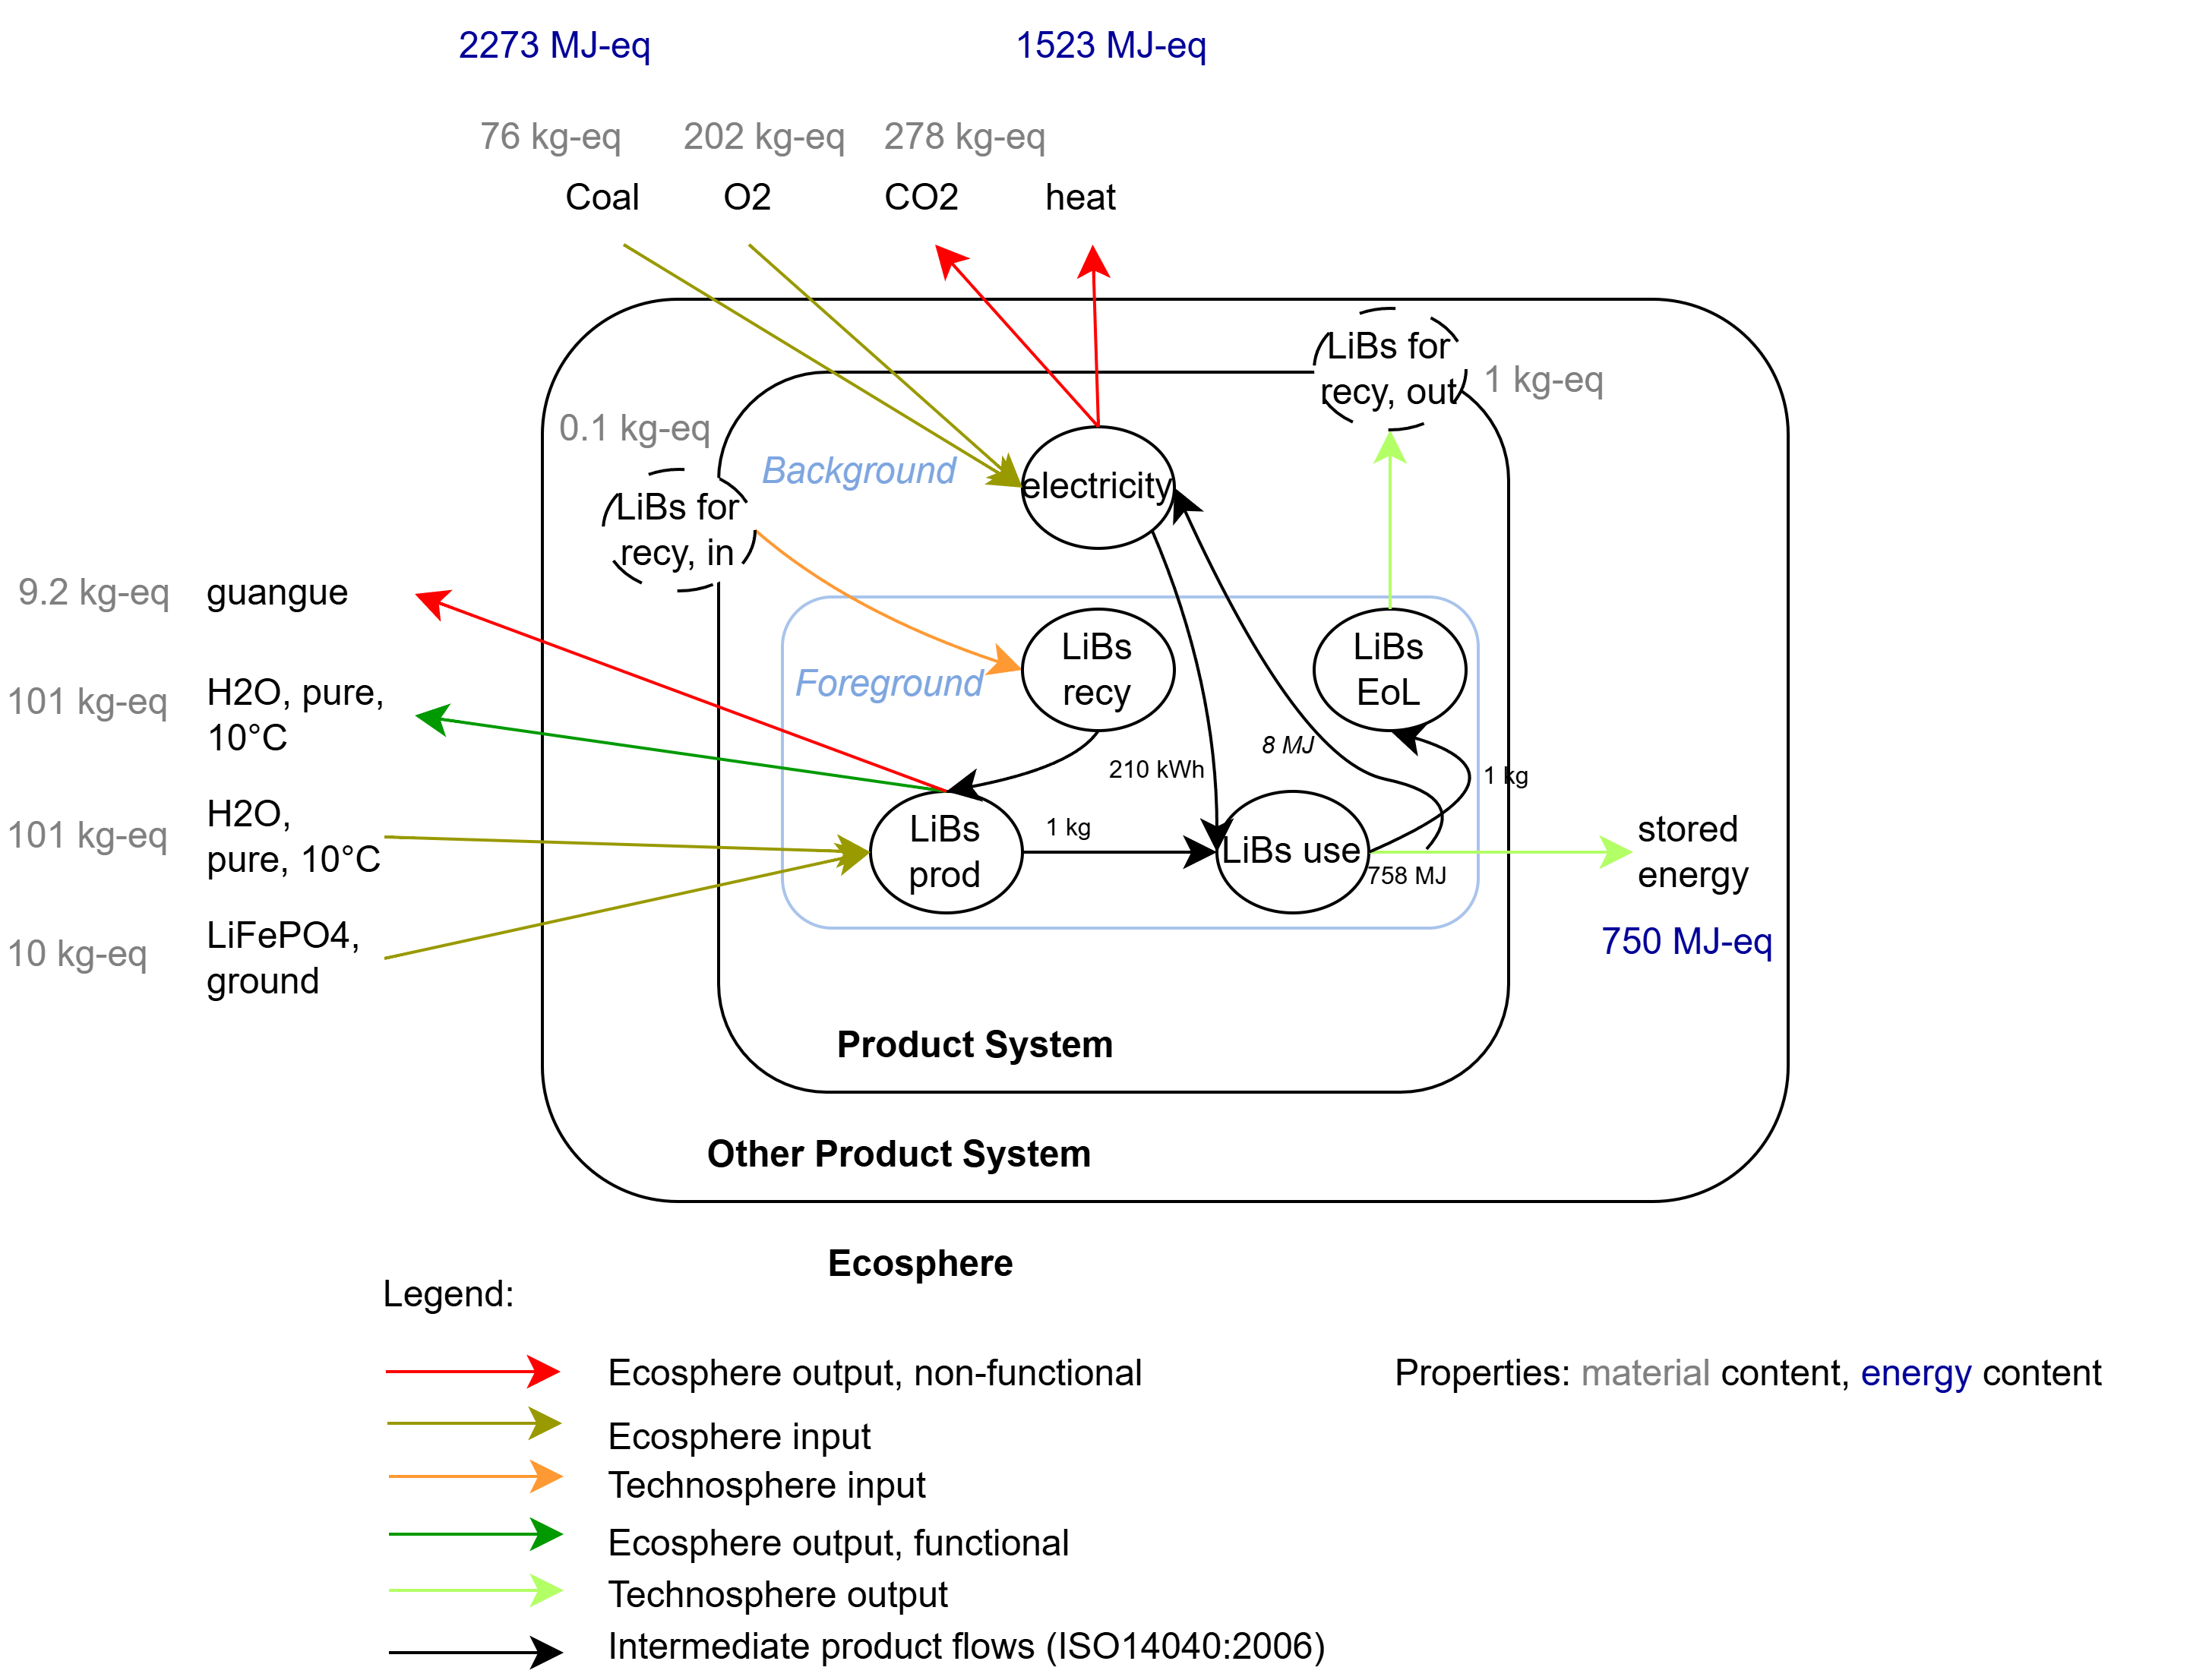

In [7]:
# Diagram 5: Final Integrated Circularity - LCA Inventory Results
display(Image(filename="Figures/circularity-LCA_+LCIres.png"))

## LCIA 

In [8]:
bd.projects.set_current(project_name)

lcia_builder = clci.LCIAMethodBuilder(
    project_name=project_name,
    excluded_flows=excluded_flows,
    valuable_water_compartments=valuable_water_compartments,
    exclude_water=exclude_water,
    technosphere_db_name=technosphere_db_name,
    biosphere_db_name=biosphere_db_name,
    mass_strategy=mass_strategy,
    energy_strategy=energy_strategy
)

# Create all 44 methods
all_methods = lcia_builder.create_all_methods()
# Create 32 mass methods
# mass_lcia = lcia_builder.create_all_mass_methods(include_water=True)
# # Create 12 energy methods
# energy_lcia = lcia_builder.create_all_energy_methods()

In [11]:
analyzer = clci.CircularityDatabaseAnalyzer(
    project_name = bd.projects.current,
    isic_section_map=isic_section_map, # isic_section_map is defined in "Ecoinvent" Section
    isic_division_map=isic_division_map,
    location_to_un_group=location_to_un_group,
    excluded_flows=excluded_flows,
    valuable_water_compartments=valuable_water_compartments,
    exclude_water=exclude_water,
    technosphere_db_name=technosphere_db_name,
    biosphere_db_name=biosphere_db_name,
    mass_strategy=mass_strategy,
    energy_strategy=energy_strategy
)

# unitprocesses_number = 1000
# Compute circularity for all processes
# results_df = analyzer.compute_circularity_for_all_processes_sequential(sample_size=unitprocesses_number)
results_df = analyzer.compute_circularity_for_all_processes_sequential()
results_df.head()

,Process Key,Process Name,Location,Reference Product,Unit,ISIC Code,ISIC Division,ISIC Section,ISIC Description,LOCATION Code,...,CFI_kg,V_MJ,Ri_MJ,Rr_MJ,Er_MJ,W_MJ,eta-_MJ,eta+_MJ,LFI_MJ,CFI_MJ
0,"(None-None-cutoff, libs_outputs_eol_cutoff)",LiBs Outputs EoL (cut-off),FR,Unknown,kilogram,Unknown,Unknown,Unknown,Unknown,FR,...,1.000000,0.000000,0.0,0.0,0.0,0.000000,0.00,0.00,0.000,0.000
1,"(None-None-cutoff, electricity_production)",Electricity production,FR,Unknown,kilowatt hour,Unknown,Unknown,Unknown,Unknown,FR,...,0.002126,10.909091,0.0,3.6,0.0,7.309091,0.67,0.33,0.835,0.165
2,"(None-None-cutoff, libs_use)",LiBs use,FR,stored electricity,megajoule,Unknown,Unknown,Unknown,Unknown,FR,...,0.015412,3.030303,0.0,1.0,0.0,2.030303,0.67,0.33,0.835,0.165
3,"(None-None-cutoff, libs_inputs_eol_cutoff)",LiBs Inputs EoL (cut-off),FR,Unknown,kilogram,Unknown,Unknown,Unknown,Unknown,FR,...,1.000000,0.000000,0.0,0.0,0.0,0.000000,0.00,0.00,0.000,0.000
4,"(None-None-cutoff, libs_production)",LiBs production,FR,Unknown,kilogram,Unknown,Unknown,Unknown,Unknown,FR,...,0.050409,0.000000,0.0,0.0,0.0,0.000000,0.00,0.00,0.000,0.000


## comparison plot

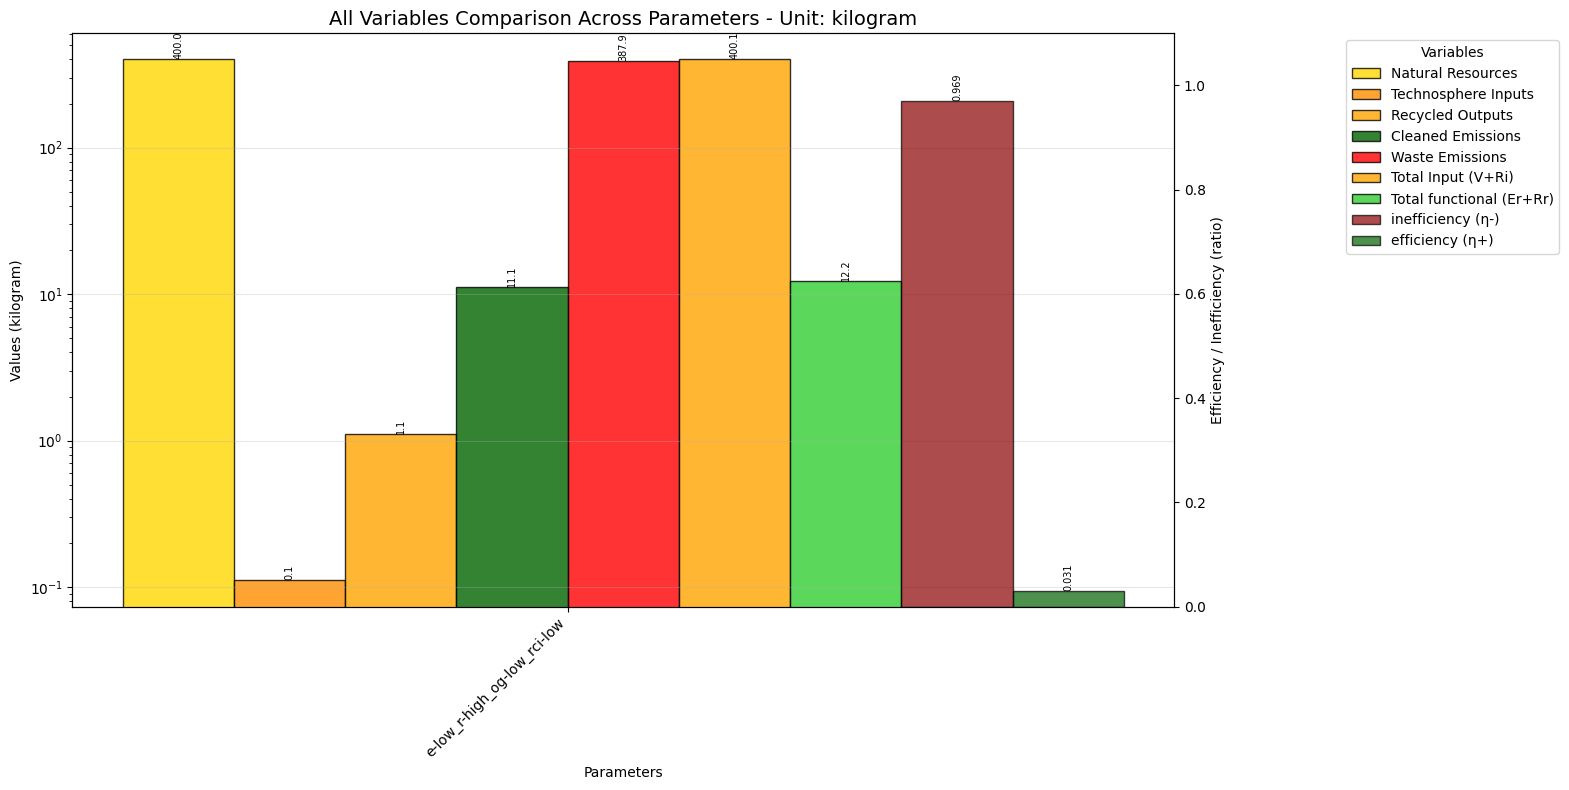

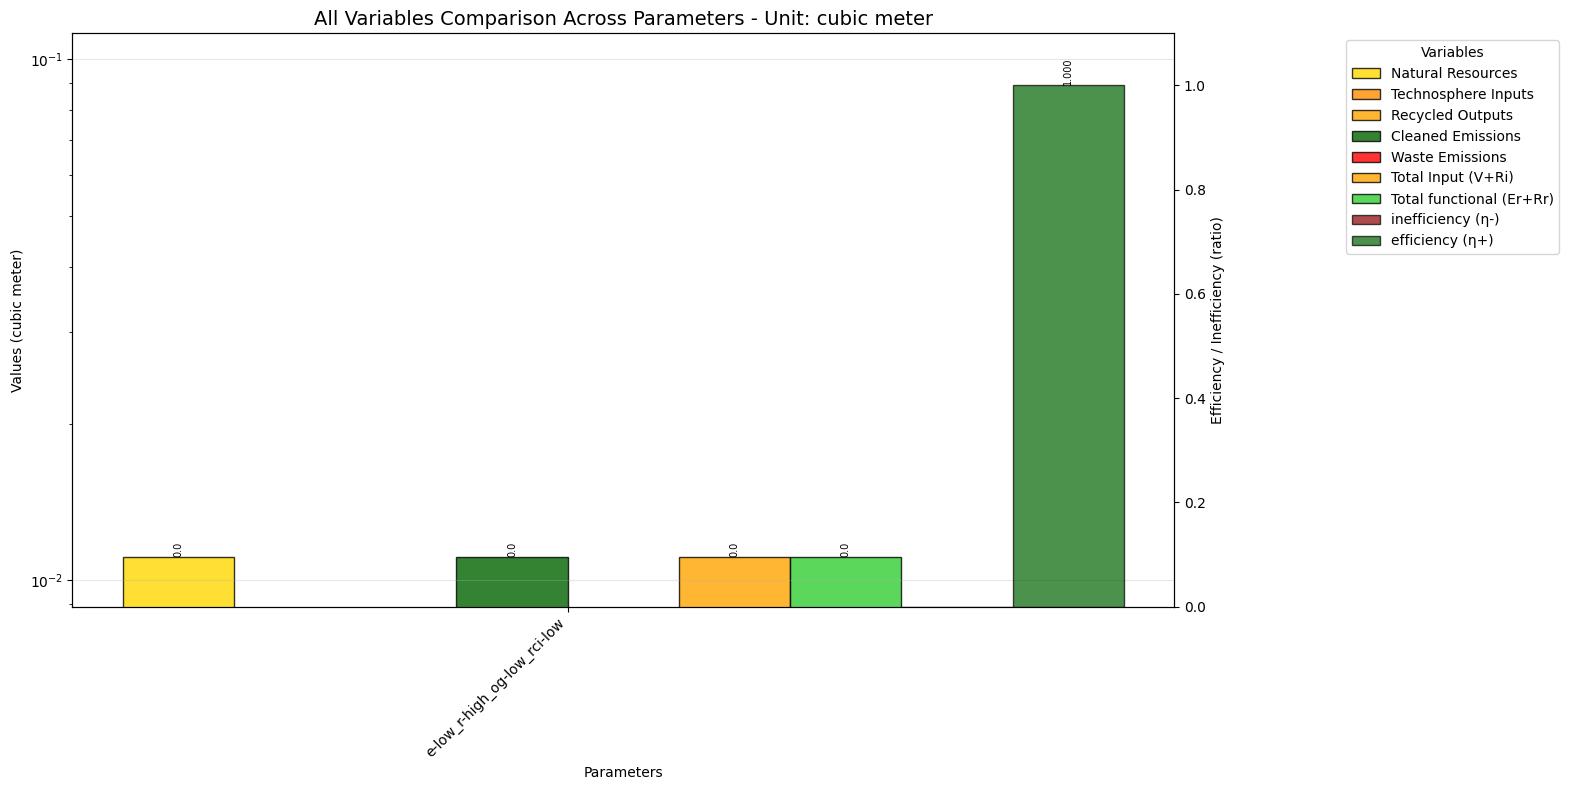

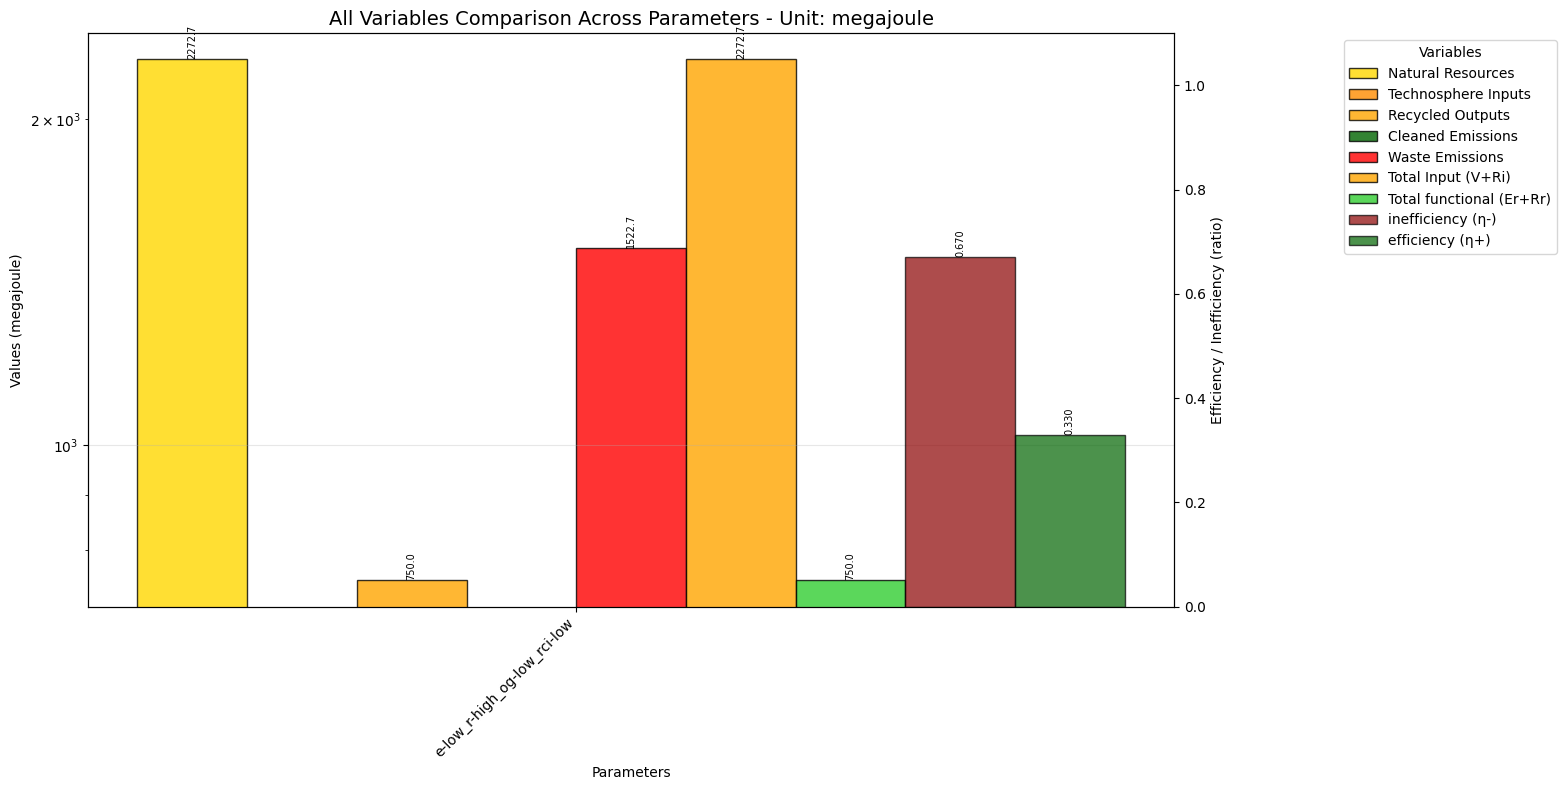

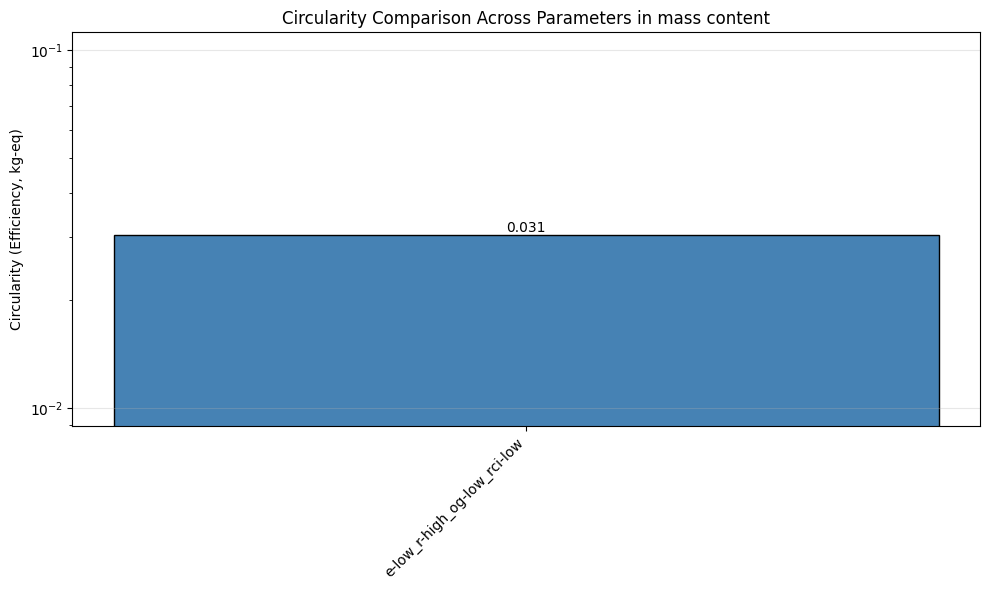


SENSITIVITY ANALYSIS SUMMARY
e-low_r-high_og-low_rci-low: 0.0305

Max circularity: 0.0305 (e-low_r-high_og-low_rci-low)
Min circularity: 0.0305 (e-low_r-high_og-low_rci-low)


In [12]:
# Find all circularity CSV files
csv_files = glob.glob(f"results/csv/{project_name}/circularity_results_for_*.csv")

if csv_files:
    results = []
    
    # Extract parameter names and data
    for file in csv_files:
        df = pd.read_csv(file, index_col=0)  # Read with first column as index (units)
        param_name = os.path.basename(file).replace("circularity_results_for_", "").replace(".csv", "")
        
        # Store the entire dataframe for this parameter
        results.append((param_name, df))
    
    # Get all variable names (columns) from the first dataframe
    variables = results[0][1].columns.tolist()
    units = results[0][1].index.tolist()
    
    # Separate variables into absolute values and ratios
    ratio_vars = ['inefficiency (η-)', 'efficiency (η+)']
    abs_vars = [var for var in variables if var not in ratio_vars]
    
    # Define custom color mapping for absolute variables
    color_map = {
        # Natural resources - yellow
        'Natural Resources': 'gold',
        
        # Waste - red
        'Waste Emissions': 'red',
        
        # Technosphere inputs - orange
        'Technosphere Inputs': 'darkorange',
        'Recycled Outputs': 'orange',  # Technosphere outputs - light green
        'Total Input (V+Ri)': 'orange',  # Also technosphere input
        
        # Ecosphere functional output - dark green (Cleaned Emissions)
        'Cleaned Emissions': 'darkgreen',
        'Total functional (Er+Rr)': 'limegreen',  # Light green for functional outputs
    }
    
    # Create a separate plot for each unit
    for unit_idx, unit in enumerate(units):
        fig, ax1 = plt.subplots(figsize=(16, 8))
        
        # Collect data for this unit across all parameters
        param_names = []
        abs_values = {var: [] for var in abs_vars}
        ratio_values = {var: [] for var in ratio_vars}
        
        for param_name, df in results:
            param_names.append(param_name)
            for var in abs_vars:
                abs_values[var].append(df.loc[unit, var] if unit in df.index else np.nan)
            for var in ratio_vars:
                ratio_values[var].append(df.loc[unit, var] if unit in df.index else np.nan)
        
        # Set up bar positions - all variables in a row per parameter
        n_abs_vars = len(abs_vars)
        n_ratio_vars = len(ratio_vars)
        total_vars = n_abs_vars + n_ratio_vars
        width = 0.8 / total_vars  # Width of each bar
        
        # DEFINE x HERE - base positions for each parameter
        x = np.arange(len(param_names))
        
        # Calculate starting offset to center the group of bars
        start_offset = - (total_vars - 1) * width / 2
        
        # Plot bars for absolute variables on left axis with custom colors
        for i, var in enumerate(abs_vars):
            # Get color from map, default to steelblue if not found
            color = color_map.get(var, 'steelblue')
            
            # Simple sequential positioning
            x_positions = x + start_offset + (i + 0.5) * width
            bars = ax1.bar(x_positions, abs_values[var], width, 
                          label=var, color=color, edgecolor='black', alpha=0.8)
            
            # Add value labels on top of bars
            for bar in bars:
                height = bar.get_height()
                if not np.isnan(height) and height > 0:
                    ax1.text(bar.get_x() + bar.get_width()/2., height,
                            f'{height:.1f}', ha='center', va='bottom', fontsize=7, rotation=90)
        
        ax1.set_xlabel('Parameters')
        ax1.set_ylabel(f'Values ({unit})', color='black')
        ax1.tick_params(axis='y', labelcolor='black')
        ax1.grid(True, alpha=0.3, axis='y')
        
        # Set log scale for left axis
        ax1.set_yscale('log')
        
        # Create second y-axis for ratio variables
        ax2 = ax1.twinx()
        
        # Plot ratio variables on right axis - continue sequential positioning
        colors_ratio = ['darkred', 'darkgreen']
        
        for i, var in enumerate(ratio_vars):
            # Position ratio bars after absolute bars (i starts from 0 for ratio vars)
            var_index = n_abs_vars + i  # Sequential index for all variables
            x_positions = x + start_offset + (var_index + 0.5) * width
            bars = ax2.bar(x_positions, ratio_values[var], width,
                          label=var, color=colors_ratio[i], edgecolor='black', alpha=0.7)
            
            # Add value labels on top of bars
            for bar in bars:
                height = bar.get_height()
                if not np.isnan(height) and height > 0:
                    ax2.text(bar.get_x() + bar.get_width()/2., height,
                            f'{height:.3f}', ha='center', va='bottom', fontsize=7, rotation=90)
        
        ax2.set_ylabel('Efficiency / Inefficiency (ratio)', color='black')
        ax2.tick_params(axis='y', labelcolor='black')
        ax2.set_ylim(0, 1.1)  # Ratios between 0 and 1
        
        # Customize plot
        plt.title(f'All Variables Comparison Across Parameters - Unit: {unit}', fontsize=14)
        ax1.set_xticks(x)
        ax1.set_xticklabels(param_names, rotation=45, ha='right')
        
        # Combine legends from both axes
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, title='Variables', 
                  bbox_to_anchor=(1.15, 1), loc='upper left')
        
        plt.tight_layout()
        plt.savefig(f"results/images/{project_name}/sensitivity_unit_{unit.replace(' ', '_')}.png", dpi=300)
        plt.show()
    
    # Also create summary circularity plot (original behavior)
    circularity_results = []
    for param_name, df in results:
        # Extract circularity (efficiency) - using the last column
        if 'efficiency (η+)' in df.columns:
            circ_value = df['efficiency (η+)'].iloc[0]
        else:
            circ_value = df.iloc[0, -1]  # Last column, first row => kilogram
        circularity_results.append((param_name, circ_value))
    
    circularity_results.sort(key=lambda x: x[1])
    params, circ_values = zip(*circularity_results)
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(params, circ_values, color='steelblue', edgecolor='black')
    plt.ylabel('Circularity (Efficiency, kg-eq)')
    plt.title('Circularity Comparison Across Parameters in mass content')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')
    
    # Set log scale for the summary plot
    plt.yscale('log')
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig(f"results/images/{project_name}/sensitivity_comparison.png", dpi=300)
    plt.show()
    
    # Print summary
    print("\n" + "="*50)
    print("SENSITIVITY ANALYSIS SUMMARY")
    print("="*50)
    for param, circ in zip(params, circ_values):
        print(f"{param}: {circ:.4f}")
    print(f"\nMax circularity: {max(circ_values):.4f} ({params[circ_values.index(max(circ_values))]})")
    print(f"Min circularity: {min(circ_values):.4f} ({params[circ_values.index(min(circ_values))]})")
    
else:
    print("No CSV files found. Run circularity calculations first.")

## Section's CCLs

- ➕ Communicative purpose, e.g.:
    best-performing parameter (e-high_r-low_og-low_rci-low) achieves **54.7%** circularity (efficiency) — the highest among all configurations.
    In contrast, the worst-performing parameter (e-low_r-low_og-low_rci-low) has lower circularity (**45.3%**) 
    Higher circularity (54.7%) is achieved with significantly lower resource consumption and waste (263.9 kg vs 388.9 kg), but this requires higher electricity production efficiency (40% vs 33%)
- ⚠️ Reliability: Circularity varies significantly by unit (kg, MJ, m³). One system can be highly circular on an energy basis (60%) but poor on a mass basis (4%).
- ⚠️ Decision-making requires weighting (e.g., MCDA) and full LCA, not just circularity scores.

# Ecoinvent

In [3]:
import bw2io as bi # import ei
import json


# For the plot:
%matplotlib ipympl
import pickle
import seaborn as sns
import matplotlib.ticker as ticker
import mplcursors
import numpy as np

## init the project

In [ ]:
database_provider = "ecoinvent"   # works for "ecoinvent" (ei) or "bafu"
ecospold_folder = None # if the import is based on spold file

# for ei:
ei_username = os.getenv("EI_USERNAME")
ei_password = os.getenv("EI_PASSWORD")

database_version = "3.12" # for ei
database_systemmodel = "consequential" # can be 'cutoff', 'apos', and 'consequential' (ecoinvent) or 'not-precised' for (bafu)

# For project naming conventions
# In init flow treatment, we can choose to ignore the flows that have in their names: "water" (high influence on the total mass)
water_suffix = "no-w" if exclude_water else "all"

# mass strategy
if mass_strategy == "full_mass":
     mass_suffix = "fm" 
elif mass_strategy == "water_mass":
     mass_suffix = "wm"
elif mass_strategy == "dry_mass":
     mass_suffix = "dm"
# energy strategy   
if energy_strategy == "full_energy":
     energy_suffix = "fe" 
elif energy_strategy == "renewable_energy":
     energy_suffix = "re"
elif energy_strategy == "non-renewable_energy":
     energy_suffix = "nre"

project_name = f"{database_provider}-{database_version}-{database_systemmodel}_{mass_suffix}-{energy_suffix}"
# With water suffix: project_name = f"{subject}_{method}_{software_provider}-{software_version}_{database_provider}-{database_version}-{database_systemmodel}_{water_suffix}"

technosphere_db_name = f"{database_provider}-{database_version}-{database_systemmodel}"
biosphere_db_name = f"{database_provider}-{database_version}-biosphere" if database_provider == "ecoinvent" else "biosphere3"

def setup_project(): #also in functions.py file
        """Set up a new Brightway2 project and import ecoinvent if missing"""
        if project_name not in bd.projects:
            bd.projects.create_project(project_name)
        bd.projects.set_current(project_name)
        print(f"The project '{project_name}' is set as current.")
        # the principles are applied to the most used LCA database, ecoinvent [https://ecochain.com/blog/lci-databases-in-lca/]
        # the cutoff system model is the simplest to understand [https://support.ecoinvent.org/system-models-1]
        if technosphere_db_name not in bd.databases:
            if database_provider == "ecoinvent":
                print(f"Importing {technosphere_db_name} database...")
                bi.import_ecoinvent_release(
                    database_version,
                    database_systemmodel,
                    ei_username,
                    ei_password
                )
        print("Setup" \
        " complete.")
        setup_complete = True

setup_project()    

The project 'ecoinvent-3.12-consequential_fm-fe' is set as current.
Setup complete.


## Cut-off act screening

In [15]:
bf_analyzer = clci.BurdenFreeAnalyzer(
    project_name=project_name,
    database_provider=database_provider,
    ecospold_folder=ecospold_folder,
    technosphere_db_name=technosphere_db_name,
    database_version=database_version,
    database_systemmodel=database_systemmodel
)

bf_analyzer.setup_project()  
burden_free_activities = bf_analyzer.analyze_all_databases() # to be run one time per project if biosphere flow manager has operate  

In [16]:
counts = bf_analyzer.count_activities_in_json(
    filename="ecoinvent-3.12-consequential_fm-fe_added_product_flows.json"
)
counts

{'ecoinvent-3.12-biosphere': 0, 'ecoinvent-3.12-consequential': 192}

### analysis

In [17]:


JSON_PATH = "results/json/ecoinvent-3.12-consequential_fm-fe_added_product_flows.json"


def _count_exchanges(proc):
    """Count exchanges of each type for a single process."""
    counts = {"production": 0, "technosphere": 0, "biosphere": 0}
    for exc in proc.exchanges():
        t = exc.get("type", "")
        if t in counts:
            counts[t] += 1
    return counts


def profile_from_json(json_path):
    """Read JSON, search each process in bw2data, return one profile DataFrame."""
    with open(json_path, "r") as f:
        data = json.load(f)

    rows = []
    for db_name, act_list in data.items():
        if not act_list:
            continue
        db = bd.Database(db_name)
        for entry in act_list:
            code = entry.get("code")
            if not code:
                continue
            proc = db.get(code) # type: ignore
            if proc is None:
                continue
            meta = proc.as_dict()
            counts = _count_exchanges(proc)
            rows.append({
                "database": db_name,
                "name": meta.get("name"),
                "location": meta.get("location"),
                # "code": code,
                "reference_product": meta.get("reference product"),
                "unit": meta.get("unit"),
                "production_amount": meta.get("production amount"),
                "activity_type": meta.get("activity type"),
                # "start_date": meta.get("start_date"),
                # "end_date": meta.get("end_date"),
                # "n_production": counts["production"],
                # "n_technosphere": counts["technosphere"],
                # "n_biosphere": counts["biosphere"],
                "n_exchanges_total": sum(counts.values()),
            })
    return pd.DataFrame(rows)

df = profile_from_json(JSON_PATH)
df
# df.to_csv(f"results/csv/{project_name}/ecoinvent-3.12-consequential_fm-fe_added_product_flows_profile.csv", index=False)

,database,name,location,reference_product,unit,production_amount,activity_type,n_exchanges_total
0,ecoinvent-3.12-consequential,clinker production,RoW,copper slag,kilogram,-1.0,ordinary transforming activity,2
1,ecoinvent-3.12-consequential,"cement production, CP V RS",BR,nickel smelter slag,kilogram,-1.0,ordinary transforming activity,2
2,ecoinvent-3.12-consequential,clinker production,RoW,zinc slag,kilogram,-1.0,ordinary transforming activity,2
3,ecoinvent-3.12-consequential,"cement production, CEM IV/A",RoW,hard coal ash,kilogram,-1.0,ordinary transforming activity,2
4,ecoinvent-3.12-consequential,clinker production,CO,inert waste,kilogram,-1.0,ordinary transforming activity,2
...,...,...,...,...,...,...,...,...
187,ecoinvent-3.12-consequential,"clinker production, average",CA,"waste building wood, chrome preserved",kilogram,-1.0,ordinary transforming activity,2
188,ecoinvent-3.12-consequential,clinker production,CO,"sewage sludge, dried",kilogram,-1.0,ordinary transforming activity,2
189,ecoinvent-3.12-consequential,clinker production,RoW,biowaste,kilogram,-1.0,ordinary transforming activity,2
190,ecoinvent-3.12-consequential,clinker production,RoW,waste foundry sand,kilogram,-1.0,ordinary transforming activity,2


## Cut-off product flow duplication

In [19]:
# if you run it, you transform the cut-off unit processes in non-cut-off unit processes.
# running the second time will have no effects 
biosphere_flow_manager = clci.BiosphereFlowManager(biosphere_db_name)   # type: ignore
biosphere_flow_manager.process(burden_free_activities)

## Plots by Isic Sections

### isic map dictionaries

In [10]:

# Mapping Section -> Full name
isic_section_map = {
    "A": "Agriculture, forestry and fishing",
    "B": "Mining and quarrying",
    "C": "Manufacturing",
    "D": "Electricity, gas, steam and air conditioning supply",
    "E": "Water supply; sewerage, waste management and remediation",
    "F": "Construction",
    "G": "Wholesale and retail trade; repair of motor vehicles",
    "H": "Transportation and storage",
    "I": "Accommodation and food service activities",
    "J": "Information and communication",
    "K": "Financial and insurance activities",
    "L": "Real estate activities",
    "M": "Professional, scientific and technical activities",
    "N": "Administrative and support service activities",
    "O": "Public administration and defence; compulsory social security",
    "P": "Education",
    "Q": "Human health and social work activities",
    "R": "Arts, entertainment and recreation",
    "S": "Other service activities",
    "T": "Activities of households as employers",
    "U": "Activities of extraterritorial organizations"
}
# Mapping Division
isic_division_map = {
    # SECTION A: Agriculture, forestry and fishing
    "01": ("A", "Crop and animal production, hunting and related service activities"),
    "02": ("A", "Forestry and logging"),
    "03": ("A", "Fishing and aquaculture"),

    # SECTION B: Mining and quarrying
    "05": ("B", "Mining of coal and lignite"),
    "06": ("B", "Extraction of crude petroleum and natural gas"),
    "07": ("B", "Mining of metal ores"),
    "08": ("B", "Other mining and quarrying"),
    "09": ("B", "Mining support service activities"),

    # SECTION C: Manufacturing
    "10": ("C", "Manufacture of food products"),
    "11": ("C", "Manufacture of beverages"),
    "12": ("C", "Manufacture of tobacco products"),
    "13": ("C", "Manufacture of textiles"),
    "14": ("C", "Manufacture of wearing apparel"),
    "15": ("C", "Manufacture of leather and related products"),
    "16": ("C", "Manufacture of wood and of products of wood and cork, except furniture; manufacture of articles of straw and plaiting materials"),
    "17": ("C", "Manufacture of paper and paper products"),
    "18": ("C", "Printing and reproduction of recorded media"),
    "19": ("C", "Manufacture of coke and refined petroleum products"),
    "20": ("C", "Manufacture of chemicals and chemical products"),
    "21": ("C", "Manufacture of basic pharmaceutical products and pharmaceutical preparations"),
    "22": ("C", "Manufacture of rubber and plastics products"),
    "23": ("C", "Manufacture of other non-metallic mineral products"),
    "24": ("C", "Manufacture of basic metals"),
    "25": ("C", "Manufacture of fabricated metal products, except machinery and equipment"),
    "26": ("C", "Manufacture of computer, electronic and optical products"),
    "27": ("C", "Manufacture of electrical equipment"),
    "28": ("C", "Manufacture of machinery and equipment n.e.c."),
    "29": ("C", "Manufacture of motor vehicles, trailers and semi-trailers"),
    "30": ("C", "Manufacture of other transport equipment"),
    "31": ("C", "Manufacture of furniture"),
    "32": ("C", "Other manufacturing"),
    "33": ("C", "Repair and installation of machinery and equipment"),

    # SECTION D: Electricity, gas, steam and air conditioning supply
    "35": ("D", "Electricity, gas, steam and air conditioning supply"),

    # SECTION E: Water supply; sewerage, waste management and remediation activities
    "36": ("E", "Water collection, treatment and supply"),
    "37": ("E", "Sewerage"),
    "38": ("E", "Waste collection, treatment and disposal activities; materials recovery"),
    "39": ("E", "Remediation activities and other waste management services"),

    # SECTION F: Construction
    "41": ("F", "Construction of buildings"),
    "42": ("F", "Civil engineering"),
    "43": ("F", "Specialized construction activities"),

    # SECTION G: Wholesale and retail trade; repair of motor vehicles and motorcycles
    "45": ("G", "Wholesale and retail trade and repair of motor vehicles and motorcycles"),
    "46": ("G", "Wholesale trade, except of motor vehicles and motorcycles"),
    "47": ("G", "Retail trade, except of motor vehicles and motorcycles"),

    # SECTION H: Transportation and storage
    "49": ("H", "Land transport and transport via pipelines"),
    "50": ("H", "Water transport"),
    "51": ("H", "Air transport"),
    "52": ("H", "Warehousing and support activities for transportation"),
    "53": ("H", "Postal and courier activities"),

    # SECTION I: Accommodation and food service activities
    "55": ("I", "Accommodation"),
    "56": ("I", "Food and beverage service activities"),

    # SECTION J: Information and communication
    "58": ("J", "Publishing activities"),
    "59": ("J", "Motion picture, video and television programme production, sound recording and music publishing activities"),
    "60": ("J", "Programming and broadcasting activities"),
    "61": ("J", "Telecommunications"),
    "62": ("J", "Computer programming, consultancy and related activities"),
    "63": ("J", "Information service activities"),

    # SECTION K: Financial and insurance activities
    "64": ("K", "Financial service activities, except insurance and pension funding"),
    "65": ("K", "Insurance, reinsurance and pension funding, except compulsory social security"),
    "66": ("K", "Activities auxiliary to financial service and insurance activities"),

    # SECTION L: Real estate activities
    "68": ("L", "Real estate activities"),

    # SECTION M: Professional, scientific and technical activities
    "69": ("M", "Legal and accounting activities"),
    "70": ("M", "Activities of head offices; management consultancy activities"),
    "71": ("M", "Architectural and engineering activities; technical testing and analysis"),
    "72": ("M", "Scientific research and development"),
    "73": ("M", "Advertising and market research"),
    "74": ("M", "Other professional, scientific and technical activities"),
    "75": ("M", "Veterinary activities"),

    # SECTION N: Administrative and support service activities
    "77": ("N", "Rental and leasing activities"),
    "78": ("N", "Employment activities"),
    "79": ("N", "Travel agency, tour operator, reservation service and related activities"),
    "80": ("N", "Security and investigation activities"),
    "81": ("N", "Services to buildings and landscape activities"),
    "82": ("N", "Office administrative, office support and other business support activities"),

    # SECTION O: Public administration and defence; compulsory social security
    "84": ("O", "Public administration and defence; compulsory social security"),

    # SECTION P: Education
    "85": ("P", "Education"),

    # SECTION Q: Human health and social work activities
    "86": ("Q", "Human health activities"),
    "87": ("Q", "Residential care activities"),
    "88": ("Q", "Social work activities without accommodation"),

    # SECTION R: Arts, entertainment and recreation
    "90": ("R", "Creative, arts and entertainment activities"),
    "91": ("R", "Libraries, archives, museums and other cultural activities"),
    "92": ("R", "Gambling and betting activities"),
    "93": ("R", "Sports activities and amusement and recreation activities"),

    # SECTION S: Other service activities
    "94": ("S", "Activities of membership organizations"),
    "95": ("S", "Repair of computers and personal and household goods"),
    "96": ("S", "Other personal service activities"),

    # SECTION T: Activities of households as employers; undifferentiated goods- and services-producing activities of households for own use
    "97": ("T", "Activities of households as employers of domestic personnel"),
    "98": ("T", "Undifferentiated goods- and services-producing activities of private households for own use"),

    # SECTION U: Activities of extraterritorial organizations and bodies
    "99": ("U", "Activities of extraterritorial organizations and bodies"),
}

# Dictionary: from ecoinvent location to UN regions
location_to_un_group = {
    'RME': 'Asia-Pacific',
    'TN': 'Africa',
    'BG': 'Eastern Europe',
    'UN-EASIA': 'Asia-Pacific',
    'GI': 'WEOG',
    'RS': 'Eastern Europe',
    'IN-LD': 'Asia-Pacific',
    'US-AL': 'WEOG',
    'TR': 'WEOG',
    'US-RFC': 'WEOG',
    'AE': 'Asia-Pacific',
    'AL': 'Eastern Europe',
    'AM': 'Asia-Pacific',
    'AO': 'Africa',
    'AR': 'GRULAC',
    'AT': 'WEOG',
    'AU': 'WEOG',
    'AU-NSW': 'WEOG',
    'AU-QLD': 'WEOG',
    'AU-SA': 'WEOG',
    'AU-TAS': 'WEOG',
    'AU-VIC': 'WEOG',
    'AU-WA': 'WEOG',
    'AZ': 'Asia-Pacific',
    'BA': 'Eastern Europe',
    'BD': 'Asia-Pacific',
    'BE': 'WEOG',
    'BH': 'Asia-Pacific',
    'BJ': 'Africa',
    'BN': 'Asia-Pacific',
    'BO': 'GRULAC',
    'BR': 'GRULAC',
    'BR-AC': 'GRULAC',
    'BR-AL': 'GRULAC',
    'BR-AM': 'GRULAC',
    'BR-AP': 'GRULAC',
    'BR-BA': 'GRULAC',
    'BR-CE': 'GRULAC',
    'BR-DF': 'GRULAC',
    'BR-ES': 'GRULAC',
    'BR-GO': 'GRULAC',
    'BR-MA': 'GRULAC',
    'BR-MG': 'GRULAC',
    'BR-MS': 'GRULAC',
    'BR-MT': 'GRULAC',
    'BR-North-eastern grid': 'GRULAC',
    'BR-Northern grid': 'GRULAC',
    'BR-PA': 'GRULAC',
    'BR-PB': 'GRULAC',
    'BR-PE': 'GRULAC',
    'BR-PI': 'GRULAC',
    'BR-PR': 'GRULAC',
    'BR-RJ': 'GRULAC',
    'BR-RN': 'GRULAC',
    'BR-RO': 'GRULAC',
    'BR-RR': 'GRULAC',
    'BR-RS': 'GRULAC',
    'BR-SC': 'GRULAC',
    'BR-SE': 'GRULAC',
    'BR-SP': 'GRULAC',
    'BR-South-eastern/Mid-western grid': 'GRULAC',
    'BR-Southern grid': 'GRULAC',
    'BR-TO': 'GRULAC',
    'BW': 'Africa',
    'BY': 'Eastern Europe',
    'CA': 'WEOG',
    'CA-AB': 'WEOG',
    'CA-BC': 'WEOG',
    'CA-MB': 'WEOG',
    'CA-NB': 'WEOG',
    'CA-NF': 'WEOG',
    'CA-NS': 'WEOG',
    'CA-NT': 'WEOG',
    'CA-NU': 'WEOG',
    'CA-ON': 'WEOG',
    'CA-PE': 'WEOG',
    'CA-QC': 'WEOG',
    'CA-SK': 'WEOG',
    'CA-YK': 'WEOG',
    'CD': 'Africa',
    'CG': 'Africa',
    'CH': 'WEOG',
    'CI': 'Africa',
    'CL': 'GRULAC',
    'CM': 'Africa',
    'CN': 'Asia-Pacific',
    'CN-AH': 'Asia-Pacific',
    'CN-BJ': 'Asia-Pacific',
    'CN-CCG': 'Asia-Pacific',
    'CN-CQ': 'Asia-Pacific',
    'CN-CSG': 'Asia-Pacific',
    'CN-ECGC': 'Asia-Pacific',
    'CN-FJ': 'Asia-Pacific',
    'CN-GD': 'Asia-Pacific',
    'CN-GS': 'Asia-Pacific',
    'CN-GX': 'Asia-Pacific',
    'CN-GZ': 'Asia-Pacific',
    'CN-HA': 'Asia-Pacific',
    'CN-HB': 'Asia-Pacific',
    'CN-HE': 'Asia-Pacific',
    'CN-HL': 'Asia-Pacific',
    'CN-HN': 'Asia-Pacific',
    'CN-HU': 'Asia-Pacific',
    'CN-JL': 'Asia-Pacific',
    'CN-JS': 'Asia-Pacific',
    'CN-JX': 'Asia-Pacific',
    'CN-LN': 'Asia-Pacific',
    'CN-NCGC': 'Asia-Pacific',
    'CN-NECG': 'Asia-Pacific',
    'CN-NM': 'Asia-Pacific',
    'CN-NWG': 'Asia-Pacific',
    'CN-NX': 'Asia-Pacific',
    'CN-QH': 'Asia-Pacific',
    'CN-SA': 'Asia-Pacific',
    'CN-SC': 'Asia-Pacific',
    'CN-SD': 'Asia-Pacific',
    'CN-SGCC': 'Asia-Pacific',
    'CN-SH': 'Asia-Pacific',
    'CN-SWG': 'Asia-Pacific',
    'CN-SX': 'Asia-Pacific',
    'CN-TJ': 'Asia-Pacific',
    'CN-XJ': 'Asia-Pacific',
    'CN-XZ': 'Asia-Pacific',
    'CN-YN': 'Asia-Pacific',
    'CN-ZJ': 'Asia-Pacific',
    'CO': 'GRULAC',
    'CR': 'GRULAC',
    'CU': 'GRULAC',
    'CW': 'GRULAC',
    'CY': 'WEOG',
    'CZ': 'Eastern Europe',
    'Canada without Quebec': 'WEOG',
    'DE': 'WEOG',
    'DK': 'WEOG',
    'DO': 'GRULAC',
    'DZ': 'Africa',
    'EC': 'GRULAC',
    'EE': 'Eastern Europe',
    'EG': 'Africa',
    'ENTSO-E': 'WEOG',
    'ER': 'Africa',
    'ES': 'WEOG',
    'ET': 'Africa',
    'Europe without Austria': 'WEOG',
    'Europe without Switzerland': 'WEOG',
    'Europe without Switzerland and Austria': 'WEOG',
    'FI': 'WEOG',
    'FR': 'WEOG',
    'GA': 'Africa',
    'GB': 'WEOG',
    'GE': 'Asia-Pacific',
    'GH': 'Africa',
    'GR': 'WEOG',
    'GT': 'GRULAC',
    'HK': 'Asia-Pacific',
    'HN': 'GRULAC',
    'HR': 'Eastern Europe',
    'HT': 'GRULAC',
    'HU': 'Eastern Europe',
    'IAI Area, Africa': 'Africa',
    'IAI Area, Asia, without China and GCC': 'Asia-Pacific',
    'IAI Area, EU27 & EFTA': 'WEOG',
    'IAI Area, Gulf Cooperation Council': 'Asia-Pacific',
    'IAI Area, North America': 'WEOG',
    'IAI Area, Russia & RER w/o EU27 & EFTA': 'Eastern Europe',
    'IAI Area, South America': 'GRULAC',
    'ID': 'Asia-Pacific',
    'IE': 'WEOG',
    'IL': 'Asia-Pacific',
    'IN': 'Asia-Pacific',
    'IN-AP': 'Asia-Pacific',
    'IN-AR': 'Asia-Pacific',
    'IN-AS': 'Asia-Pacific',
    'IN-BR': 'Asia-Pacific',
    'IN-CH': 'Asia-Pacific',
    'IN-CT': 'Asia-Pacific',
    'IN-DD': 'Asia-Pacific',
    'IN-DL': 'Asia-Pacific',
    'IN-DN': 'Asia-Pacific',
    'IN-Eastern grid': 'Asia-Pacific',
    'IN-GA': 'Asia-Pacific',
    'IN-GJ': 'Asia-Pacific',
    'IN-HP': 'Asia-Pacific',
    'IN-HR': 'Asia-Pacific',
    'IN-JH': 'Asia-Pacific',
    'IN-JK': 'Asia-Pacific',
    'IN-KA': 'Asia-Pacific',
    'IN-KL': 'Asia-Pacific',
    'IN-MH': 'Asia-Pacific',
    'IN-ML': 'Asia-Pacific',
    'IN-MN': 'Asia-Pacific',
    'IN-MP': 'Asia-Pacific',
    'IN-MZ': 'Asia-Pacific',
    'IN-NL': 'Asia-Pacific',
    'IN-North-eastern grid': 'Asia-Pacific',
    'IN-Northern grid': 'Asia-Pacific',
    'IN-OR': 'Asia-Pacific',
    'IN-PB': 'Asia-Pacific',
    'IN-PY': 'Asia-Pacific',
    'IN-RJ': 'Asia-Pacific',
    'IN-SK': 'Asia-Pacific',
    'IN-Southern grid': 'Asia-Pacific',
    'IN-TN': 'Asia-Pacific',
    'IN-TR': 'Asia-Pacific',
    'IN-UP': 'Asia-Pacific',
    'IN-UT': 'Asia-Pacific',
    'IN-WB': 'Asia-Pacific',
    'IN-Western grid': 'Asia-Pacific',
    'IQ': 'Asia-Pacific',
    'IR': 'Asia-Pacific',
    'IS': 'WEOG',
    'IT': 'WEOG',
    'JM': 'GRULAC',
    'JO': 'Asia-Pacific',
    'JP': 'Asia-Pacific',
    'KE': 'Africa',
    'KG': 'Asia-Pacific',
    'KH': 'Asia-Pacific',
    'KP': 'Asia-Pacific',
    'KR': 'Asia-Pacific',
    'KW': 'Asia-Pacific',
    'KZ': 'Asia-Pacific',
    'LB': 'Asia-Pacific',
    'LK': 'Asia-Pacific',
    'LT': 'Eastern Europe',
    'LU': 'WEOG',
    'LV': 'Eastern Europe',
    'LY': 'Africa',
    'MA': 'Africa',
    'MD': 'Eastern Europe',
    'ME': 'Eastern Europe',
    'MG': 'Africa',
    'MK': 'Eastern Europe',
    'MM': 'Asia-Pacific',
    'MN': 'Asia-Pacific',
    'MT': 'WEOG',
    'MU': 'Africa',
    'MX': 'GRULAC',
    'MY': 'Asia-Pacific',
    'MZ': 'Africa',
    'NA': 'Africa',
    'NE': 'Africa',
    'NG': 'Africa',
    'NI': 'GRULAC',
    'NL': 'WEOG',
    'NO': 'WEOG',
    'NORDEL': 'WEOG',
    'NP': 'Asia-Pacific',
    'NZ': 'WEOG',
    'North America without Quebec': 'WEOG',
    'OM': 'Asia-Pacific',
    'PA': 'GRULAC',
    'PE': 'GRULAC',
    'PG': 'Asia-Pacific',
    'PH': 'Asia-Pacific',
    'PK': 'Asia-Pacific',
    'PL': 'Eastern Europe',
    'PT': 'WEOG',
    'PY': 'GRULAC',
    'QA': 'Asia-Pacific',
    'RAF': 'Africa',
    'RAS': 'Asia-Pacific',
    'RER': 'Eastern Europe',
    'RER w/o CH+DE': 'Eastern Europe',
    'RER w/o DE+NL+RU': 'Eastern Europe',
    'RER w/o RU': 'Eastern Europe',
    'RLA': 'GRULAC',
    'RNA': 'GRULAC',
    'RO': 'Eastern Europe',
    'RS': 'Eastern Europe',
    'RU': 'Eastern Europe',
    'RW': 'Africa',
    'RoE': 'WEOG',
    'RoW': 'Rest of World',
    'Russia (Asia)': 'Asia-Pacific',
    'SA': 'Asia-Pacific',
    'SAS': 'Asia-Pacific',
    'SD': 'Africa',
    'SE': 'WEOG',
    'SG': 'Asia-Pacific',
    'SI': 'Eastern Europe',
    'SK': 'Eastern Europe',
    'SN': 'Africa',
    'SS': 'Africa',
    'SV': 'GRULAC',
    'SY': 'Asia-Pacific',
    'TG': 'Africa',
    'TH': 'Asia-Pacific',
    'TJ': 'Asia-Pacific',
    'TM': 'Asia-Pacific',
    'TN': 'Africa',
    'TR': 'WEOG',
    'TT': 'GRULAC',
    'TW': 'Asia-Pacific',
    'TZ': 'Africa',
    'UA': 'Eastern Europe',
    'UCTE': 'WEOG',
    'UCTE without Germany': 'WEOG',
    'UN-EASIA': 'Asia-Pacific',
    'UN-OCEANIA': 'Asia-Pacific',
    'UN-SEASIA': 'Asia-Pacific',
    'US': 'WEOG',
    'US-ASCC': 'WEOG',
    'US-CA': 'WEOG',
    'US-CO': 'WEOG',
    'US-FL': 'WEOG',
    'US-HICC': 'WEOG',
    'US-IA': 'WEOG',
    'US-ID': 'WEOG',
    'US-IL': 'WEOG',
    'US-IN': 'WEOG',
    'US-LA': 'WEOG',
    'US-MN': 'WEOG',
    'US-MRO': 'WEOG',
    'US-ND': 'WEOG',
    'US-NE': 'WEOG',
    'US-NPCC': 'WEOG',
    'US-OH': 'WEOG',
    'US-OR': 'WEOG',
    'US-PR': 'WEOG',
    'US-RFC': 'WEOG',
    'US-SD': 'WEOG',
    'US-SERC': 'WEOG',
    'US-TRE': 'WEOG',
    'US-WA': 'WEOG',
    'US-WECC': 'WEOG',
    'US-WI': 'WEOG',
    'UY': 'GRULAC',
    'UZ': 'Asia-Pacific',
    'VE': 'GRULAC',
    'VN': 'Asia-Pacific',
    'WECC': 'WEOG',
    'WEU': 'WEOG',
    'XK': 'Eastern Europe',
    'YE': 'Asia-Pacific',
    'ZA': 'Africa',
    'ZM': 'Africa',
    'ZW': 'Africa',
    'GLO': 'Global',
} # should be in input

### plot

#### function

In [8]:
def plot_cross_indicator_scatter(results_df, save_path="basic_plots", group_by="section", isic_section_map=None):
    """
    Create hybrid-scale scatter plots comparing indicators (LFI vs CFI, eta+ vs eta-) 
    for both kg and MJ bases, grouped by ISIC or location.
    """

    if results_df.empty:
        print("No data to plot.")
        return

    # Map grouping column
    group_cols = {
        "section": "ISIC Section",
        "division": "ISIC Division", 
        "description": "ISIC Description",
        "location": "LOCATION Code",
        "un_group": "UN Group"
    }
    col = group_cols.get(group_by.lower())
    if not col:
        raise ValueError("group_by must be 'section', 'division', 'description', 'location', or 'un_group'")

    os.makedirs(save_path, exist_ok=True)
    
    # Get unique groups and sort them for consistent color assignment
    unique_groups = sorted(results_df[col].dropna().unique())
    n_groups = len(unique_groups)
    
    # USE THE SAME COLOR LOGIC AS plot_circularity_distribution
    if n_groups <= 8:
        # For few groups, use highly distinct colors
        colors = sns.color_palette("Set2", n_groups)
    elif n_groups <= 12:
        # For medium number of groups, use tab20
        colors = sns.color_palette("tab20", n_groups)
    elif n_groups <= 20:
        # For more groups, use color cube for maximum distinction
        colors = sns.color_palette("husl", n_groups)
    else:
        # For many groups, use the most distinct palette available
        colors = sns.color_palette("gist_ncar", n_groups)
        
    # Create color map with sorted groups
    color_map = dict(zip(unique_groups, colors))
    
    # CREATE LEGEND LABELS (same as in plot_circularity_distribution)
    if col == "ISIC Section" and isic_section_map is not None:
        legend_labels = []
        for group in unique_groups:
            if group in isic_section_map:
                legend_labels.append(f"{group}: {isic_section_map[group]}")
            else:
                legend_labels.append(f"{group}: Unknown")
    else:
        legend_labels = None

    # Hybrid scale transformation
    class LinearLogTransform:
        input_dims = output_dims = 1
        def transform(self, a):
            a = np.clip(a, 1e-10, None)
            return np.where(a <= 1, a, np.log10(a) + 1)
        def inverted(self):
            return InvertedLinearLogTransform()

    class InvertedLinearLogTransform:
        input_dims = output_dims = 1
        def transform(self, a):
            return np.where(a <= 1, a, 10**(a - 1))
        def inverted(self):
            return LinearLogTransform()

    linear_log_transform = LinearLogTransform()
    inverted_linear_log_transform = InvertedLinearLogTransform()

    # Define pairs to plot
    pairs = [
        # ("CFI_kg", "LFI_kg", "Circular vs Linear Flow Index (kg-eq)", "CFI (kg-eq)", "LFI (kg-eq)"),
        # ("CFI_MJ", "LFI_MJ", "Circular vs Linear Flow Index (MJ-eq)", "CFI (MJ-eq)", "LFI (MJ-eq)"),
        ("eta+_kg", "eta-_kg", "Efficiency Positive vs Negative (kg-eq)", "η⁺ (kg-eq)", "η⁻ (kg-eq)"),
        ("eta+_MJ", "eta-_MJ", "Efficiency Positive vs Negative (MJ-eq)", "η⁺ (MJ-eq)", "η⁻ (MJ-eq)")
    ]

    for x_var, y_var, title, x_label, y_label in pairs:
        fig, ax = plt.subplots(figsize=(15, 10))
        ax.set_xscale('function', functions=(linear_log_transform.transform, inverted_linear_log_transform.transform))
        ax.set_yscale('function', functions=(linear_log_transform.transform, inverted_linear_log_transform.transform))

        # Store scatter artists and subsets for hover functionality
        scatter_artists = []  # Store scatter artists
        scatter_subsets = []  # Store subset corresponding to each artist

        for grp in unique_groups:
            subset = results_df[results_df[col] == grp]

            points = ax.scatter(
                subset[x_var].values,
                subset[y_var].values,
                color=color_map[grp],
                label=grp,
                alpha=0.4,
                s=20
            )

            scatter_artists.append(points)
            scatter_subsets.append(subset.reset_index(drop=True))

        # Define plot limits and draw balanced line
        lim = [0, 1]
        ax.plot([0, 1], [1, 0], 'r--', alpha=1, label='x + y = 1 (balanced)')
        ax.xaxis.set_major_locator(ticker.FixedLocator(lim))
        ax.yaxis.set_major_locator(ticker.FixedLocator(lim))
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.set_title(f"{title} (Hybrid Scale) by {col}")
        ax.grid(True, alpha=0.3)
        
        # Apply consistent legend styling
        if legend_labels is not None:
            handles, labels = ax.get_legend_handles_labels()
            
            # Remove the balanced line from handles/labels and add it separately
            balanced_line_handle = handles[-1]
            balanced_line_label = labels[-1]
            handles = handles[:-1]
            labels = legend_labels  # Use our custom labels for the groups
            
            # Add balanced line back
            handles.append(balanced_line_handle)
            labels.append(balanced_line_label)
            
            ax.legend(
                handles=handles,
                labels=labels,
                bbox_to_anchor=(1.05, 1), 
                loc='upper left',
                title=col,
                fontsize=15,
                title_fontsize=17
            )
        else:
            ax.legend(
                bbox_to_anchor=(1.05, 1), 
                loc='upper left',
                title=col,
                fontsize=15,
                title_fontsize=17
            )
            
        fig.tight_layout()
        # fig.savefig(f"{save_path}/{x_var}_vs_{y_var}_hybrid_by_{group_by}.svg", dpi=1000, bbox_inches='tight')
        
        # Add interactive hover functionality
        # 1. Create shallow copies to 'freeze' the data for THIS specific plot
        local_artists = list(scatter_artists)
        local_subsets = list(scatter_subsets)

        # 2. Initialize cursor for this specific figure
        cursor = mplcursors.cursor(local_artists, hover=True)
        
        # 3. Create the closure, passing in the LOCAL versions of the lists
        def make_on_add(current_local_artists, current_local_subsets, c_x_var, c_y_var, c_x_label, c_y_label):
            def on_add(sel):
                try:
                    # Search only the artists belonging to this specific plot
                    artist_id = current_local_artists.index(sel.artist)
                    subset = current_local_subsets[artist_id]
                    idx = sel.index
                
                    row = subset.iloc[idx]
                    sel.annotation.set(
                        text=(
                            f"Process: {row['Process Name']}\n"
                            f"Location: {row['Location']}\n"
                            f"Reference Product: {row['Reference Product']}\n"
                            f"Group: {row[col]}\n"
                            f"{c_x_label}: {row[c_x_var]:.4f}\n"
                            f"{c_y_label}: {row[c_y_var]:.4f}"
                        ),
                        fontsize=15
                    )
                except (ValueError, IndexError):
                    # If we hover over something else (like the red line), just hide the box
                    sel.annotation.set(visible=False)
            return on_add
        
        # 4. Connect the callback using the local data
        cursor.connect("add", make_on_add(local_artists, local_subsets, x_var, y_var, x_label, y_label))
        
        plt.show()

        # Optional: close the figure if needed
        # plt.close(fig)

#### exe

✅ Loaded from conference\thursday\circularity_lci\results\pkl\pc_dup_bw-25_ecoinvent-3.12-consequential_fm-fe_1000uprs.pkl
   Shape: (1000, 29)


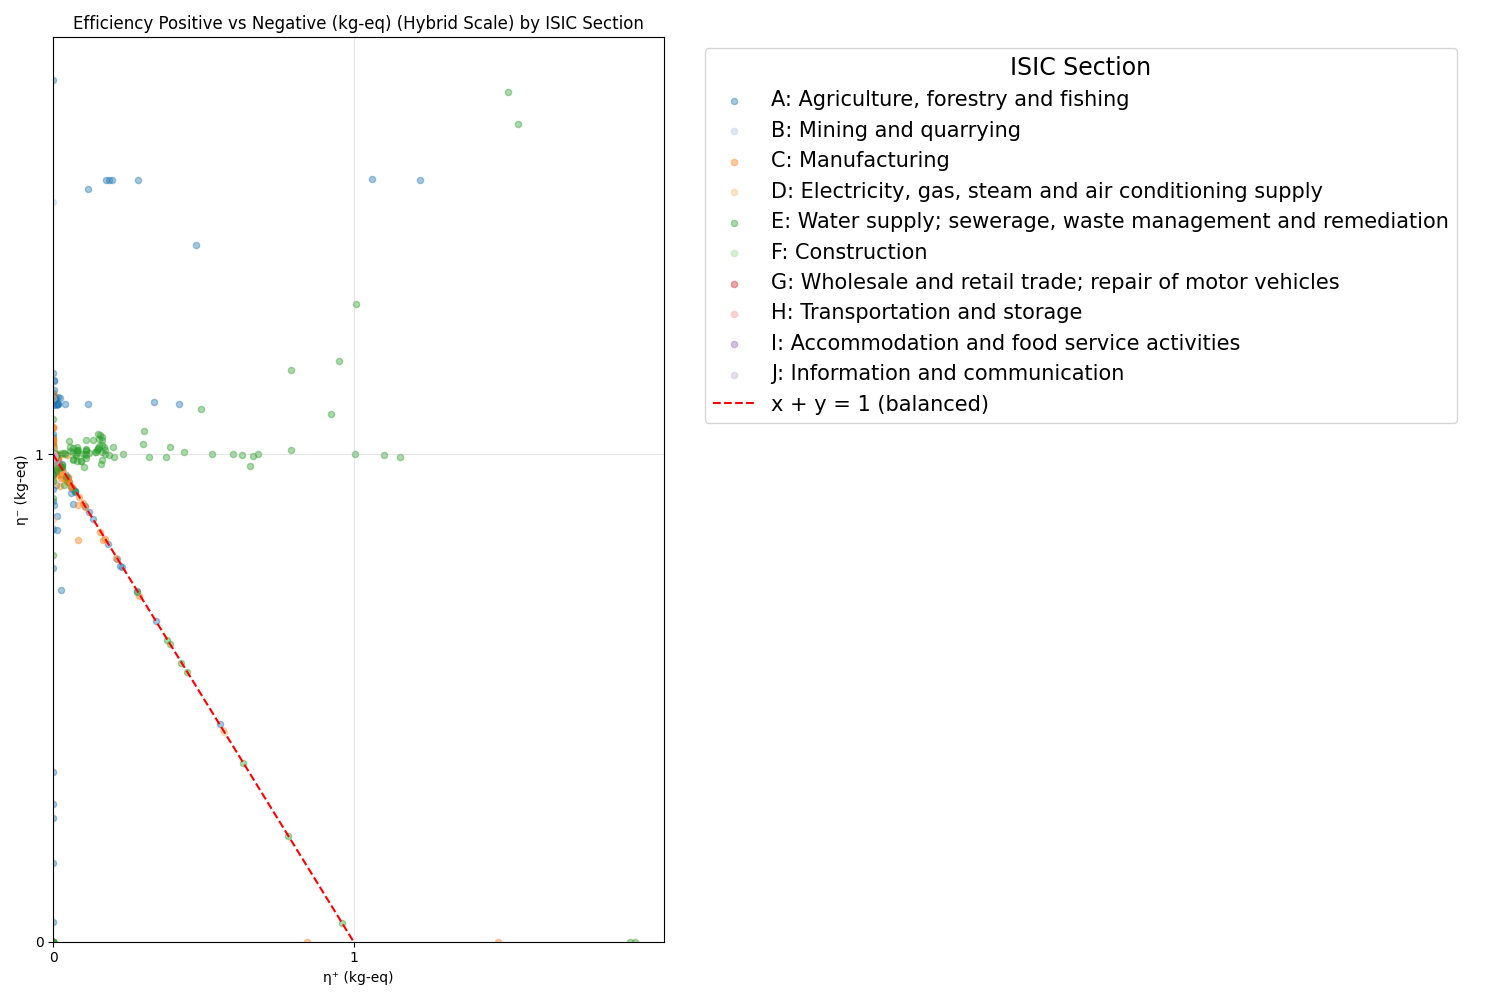

C:\Users\lfreboeuf\AppData\Local\Temp\ipykernel_22400\3766539000.py:132: UserWarning: Mismatched number of handles and labels: len(handles) = 11 len(labels) = 12
  ax.legend(


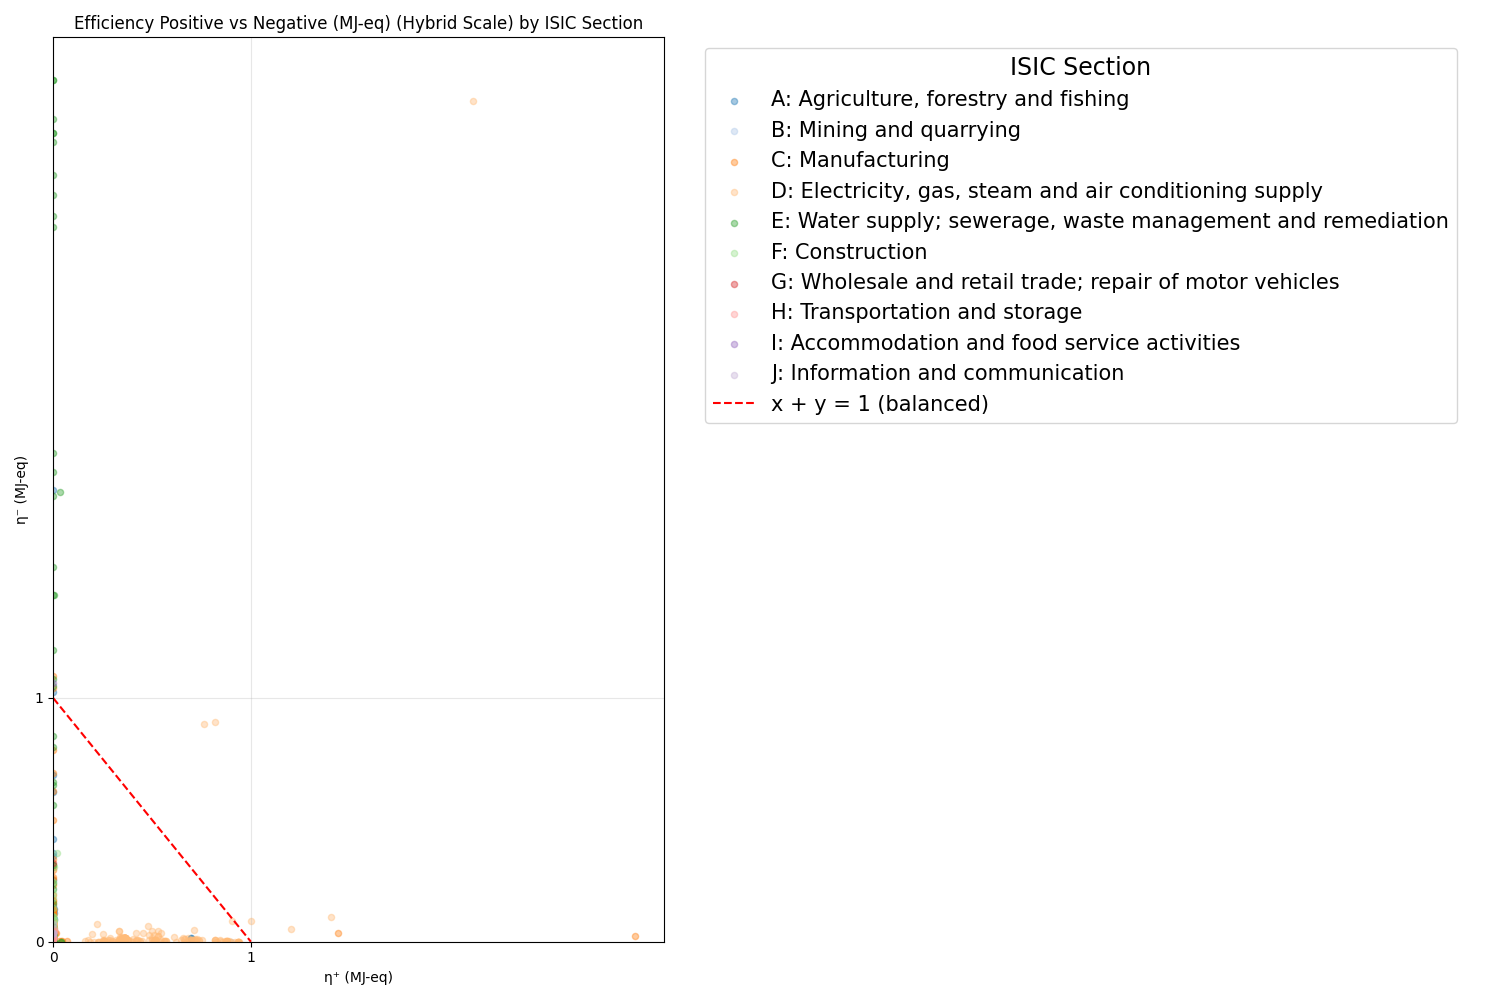

In [ ]:
def load_results_df(filename):
    """
    Load results from a pickle file in the results_pkl directory.
    The user specifies the filename, but the path is automatically set to results_pkl/.
    """
    save_dir = os.path.join("conference", "thursday", "circularity_lci", "results", "pkl")
    filepath = os.path.join(save_dir, f"{filename}.pkl")

    if os.path.exists(filepath):
        with open(filepath, 'rb') as f:
            df = pickle.load(f)
        print(f"✅ Loaded from {filepath}")
        print(f"   Shape: {df.shape}")
        return df
    else:
        raise FileNotFoundError(f"File not found: {filepath}")
    
loaded_df = load_results_df(f"pc_dup_bw-25_ecoinvent-3.12-consequential_fm-fe_1000uprs")

# Define the save path
save_path_3 = f"conference/thursday/circularity_lci/figures_{project_name}_efficiency_1000uprs"

if __name__ == "__main__":
    plot_cross_indicator_scatter(loaded_df, save_path=save_path_3, group_by="section", isic_section_map=isic_section_map)  # type: ignore load the pkl file
    # plot_cross_indicator_scatter(loaded_df, group_by="un_group")

# 🔚 Ccl

## Main findings
❌ Fail to give decision making insights on this form   
📢 Basic informations => Communication Purpose  
🪢 Expand the reflex of using LCA (and life cycle thinking) to other IE communities (circularity)  
➡️ Intrinsic circulation of a value proxy? (i.e., exergy)  

## Is this method the best?
* here:  
    New math for LCI: Screen cut-off act within $\mathbf{A}$ -> duplication in $\mathbf{B}$ -> $\mathbf{B'}$ -> + reference flow in $\mathbf{B'}$ -> $\mathbf{B''}$  
    bc.lci -> property ratio -> FILTER resource flow in $\mathbf{B''}$ -> circularity indicators <-> LCIA (wo reference flow) 
* is it the right order? e.g., bc.lci -> FILTER resource flow in $\mathbf{B''}$ -> property ratio circularity indicators <-> LCIA (wo reference flow) ?
* Can other more recognised method fit? e.g., edges  

## Limitations
* only basic circularity indicators have been computed and the energy/mass properties are too general


UPSTREAM
─────────────────────────────────────────────────────────────
screen  →  burden-free activities ('''burden_free_analyzer.py''')
   │       (1 prod, 0 tech, 0 bio)
   ▼
duplicate  →  reference product into B  →  B′ ('''biosphere_flow_manager.py''')

RUNTIME (circularity_calculator.py)
─────────────────────────────────────────────────────────────
run      →  g = B″ · A⁻¹ · f
   │
   ▼
mine     →  flows_df   (non-zero biosphere flows)
   │
   ▼
add ref  →  functional unit injected into Rr
   │        (not read from B″)
   ▼
per flow:
   screen  →  drop excluded flows (double check)
   extract →  p_i  (kg/kg, MJ/kg, …)
   select  →  mass / energy strategy
   weight  →  g_P,i = g_i · p_i
   classify→  V | Ri | Rr | Er | W
   │
   ▼
aggregate → V_m, Ri_m, Rr_m, Er_m, W_m
   │        + per-unit dicts V, Ri, Rr, Er, W
   ▼
compute  →  η⁻, η⁺           (in this method)
            CFI, LFI          (EMF)
            ISO 59020 rates
            A.3.5